# Setup

## Connect or build the database

In [1]:
import duckdb
import time
import pandas as pd
from pathlib import Path

DB_PATH = "./mimiciv.duckdb"
MIMIC_PATH = Path("../mimic/physionet.org/files/mimiciv/3.1")

HOSP = MIMIC_PATH / "hosp"
ICU = MIMIC_PATH / "icu"

# Only the tables we actually use in this project
TABLES = {
    # Hosp module: demographics, admissions, and labs
    "hosp.patients": HOSP / "patients.csv.gz",
    "hosp.admissions": HOSP / "admissions.csv.gz",
    "hosp.labevents": HOSP / "labevents.csv.gz",
    "hosp.d_labitems": HOSP / "d_labitems.csv.gz",
    # ICU module: stays, charted vitals, and IV medications
    "icu.icustays": ICU / "icustays.csv.gz",
    "icu.chartevents": ICU / "chartevents.csv.gz",
    "icu.d_items": ICU / "d_items.csv.gz",
    "icu.inputevents": ICU / "inputevents.csv.gz",
}


def load_tables(con):
    con.execute("CREATE SCHEMA IF NOT EXISTS hosp")
    con.execute("CREATE SCHEMA IF NOT EXISTS icu")
    for table_name, file_path in TABLES.items():
        if not file_path.exists():
            print(f"  SKIP {table_name}: file not found at {file_path}")
            continue
        print(f"  Loading {table_name}...", end=" ", flush=True)
        start = time.time()
        con.execute(f"DROP TABLE IF EXISTS {table_name}")
        con.execute(f"""
            CREATE TABLE {table_name} AS
            SELECT * FROM read_csv_auto('{file_path}', header=True)
        """)
        n_rows = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
        elapsed = time.time() - start
        print(f"{n_rows:,} rows in {elapsed:.1f}s")


def create_views(con):
    # Joins patients with admissions; adds hospital LOS in hours
    con.execute("""
        CREATE OR REPLACE VIEW patient_admissions AS
        SELECT
            p.subject_id, p.gender, p.anchor_age, p.anchor_year, p.dod,
            a.hadm_id, a.admittime, a.dischtime, a.deathtime,
            a.admission_type, a.admission_location, a.discharge_location,
            a.insurance, a.language, a.marital_status, a.race,
            a.hospital_expire_flag,
            EXTRACT(EPOCH FROM (a.dischtime - a.admittime)) / 3600 AS hospital_los_hours
        FROM hosp.patients p
        JOIN hosp.admissions a ON p.subject_id = a.subject_id
    """)

    # Enriches ICU stays with demographics from patient_admissions; adds ICU LOS in hours
    con.execute("""
        CREATE OR REPLACE VIEW icu_stays_full AS
        SELECT
            i.stay_id, i.subject_id, i.hadm_id,
            i.first_careunit, i.last_careunit, i.intime, i.outtime,
            EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 AS icu_los_hours,
            pa.gender, pa.anchor_age, pa.race, pa.insurance,
            pa.admission_type, pa.hospital_expire_flag, pa.dod
        FROM icu.icustays i
        JOIN patient_admissions pa ON i.hadm_id = pa.hadm_id
    """)

    # Filters chartevents to CAM/delirium assessments only; normalises values to binary 0/1
    con.execute("""
        CREATE OR REPLACE VIEW cam_icu_assessments AS
        SELECT
            ce.subject_id, ce.hadm_id, ce.stay_id, ce.charttime, ce.itemid,
            di.label AS item_label, ce.value, ce.valuenum,
            CASE 
                WHEN ce.value IN ('Positive', 'Yes', 'positive', 'yes') THEN 1
                WHEN ce.value IN ('Negative', 'No', 'negative', 'no') THEN 0
                ELSE NULL
            END AS cam_positive
        FROM icu.chartevents ce
        JOIN icu.d_items di ON ce.itemid = di.itemid
        WHERE LOWER(di.label) LIKE '%cam%'
           OR LOWER(di.label) LIKE '%delirium%'
           OR LOWER(di.label) LIKE '%confusion assessment%'
    """)

    # Aggregates CAM assessments per ICU stay: total/positive counts, ever-delirious flag, first/last assessment times
    con.execute("""
        CREATE OR REPLACE VIEW delirium_summary AS
        SELECT
            stay_id,
            COUNT(*) AS total_assessments,
            SUM(cam_positive) AS positive_assessments,
            MAX(cam_positive) AS ever_delirious,
            MIN(CASE WHEN cam_positive = 1 THEN charttime END) AS first_positive_time,
            MIN(charttime) AS first_assessment_time,
            MAX(charttime) AS last_assessment_time
        FROM cam_icu_assessments
        WHERE cam_positive IS NOT NULL
        GROUP BY stay_id
    """)

    # Joins lab results with item labels and categories for human-readable lab names and units
    con.execute("""
        CREATE OR REPLACE VIEW labs_labeled AS
        SELECT
            le.subject_id, le.hadm_id, le.charttime, le.itemid,
            dl.label AS lab_name, dl.category AS lab_category,
            le.value, le.valuenum, le.valueuom AS unit, le.flag
        FROM hosp.labevents le
        JOIN hosp.d_labitems dl ON le.itemid = dl.itemid
    """)


# Build only if the database doesn't exist; otherwise just connect
if Path(DB_PATH).exists():
    print(f"Database already exists at {DB_PATH}, connecting...")
    con = duckdb.connect(database=DB_PATH)
else:
    print(f"No database found at {DB_PATH}, building from raw files...")
    if not MIMIC_PATH.exists():
        raise FileNotFoundError(
            f"Raw MIMIC-IV files not found at {MIMIC_PATH}. "
            f"Update MIMIC_PATH at the top of this cell to point to your data."
        )
    con = duckdb.connect(database=DB_PATH)
    print("\n>>> Loading tables...")
    load_tables(con)
    print("\n>>> Creating views...")
    create_views(con)
    print(f"\nDatabase built at {DB_PATH}")

cohort_df_path = "./data/cohort.parquet"
if Path(cohort_df_path).exists():
    print(f"Loading cohort dataframe from {cohort_df_path}...")
    cohort_df = pd.read_parquet(cohort_df_path)
else:
    print(f"Cohort dataframe not found at {cohort_df_path}. Please run cohort_extraction.ipynb to create it.")

print("Connection ready.")

Database already exists at ./mimiciv.duckdb, connecting...
Loading cohort dataframe from ./data/cohort.parquet...
Connection ready.


## Helper for saving figures

In [2]:
import os
import matplotlib.pyplot as plt

os.makedirs("./figures", exist_ok=True)
os.makedirs("./data", exist_ok=True)


def save_fig(filename):
    """Save the current matplotlib figure to ./figures/ at 150 DPI."""
    path = f"./figures/{filename}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved {path}")

# Exploration

---
## - Table sizes

In [5]:
sizes = con.execute("""
    SELECT 'patients' AS table_name, COUNT(*) AS n_rows FROM hosp.patients
    UNION ALL
    SELECT 'admissions', COUNT(*) FROM hosp.admissions
    UNION ALL
    SELECT 'icu_stays', COUNT(*) FROM icu.icustays
    UNION ALL
    SELECT 'chartevents', COUNT(*) FROM icu.chartevents
    UNION ALL
    SELECT 'labevents', COUNT(*) FROM hosp.labevents
    UNION ALL
    SELECT 'inputevents', COUNT(*) FROM icu.inputevents
""").df()
print(sizes.to_string(index=False))

 table_name    n_rows
   patients    364627
 admissions    546028
  icu_stays     94458
chartevents 432997491
  labevents 158374764
inputevents  10953713


---
## - Patient demographics

In [6]:
demo = con.execute("""
    SELECT
        subject_id,
        gender,
        anchor_age 
    FROM hosp.patients
""").df()

print(f"Patients: {len(demo):,}")

Patients: 364,627


---
## - Gender distribution plot

Saved ./figures/gender_distribution.png


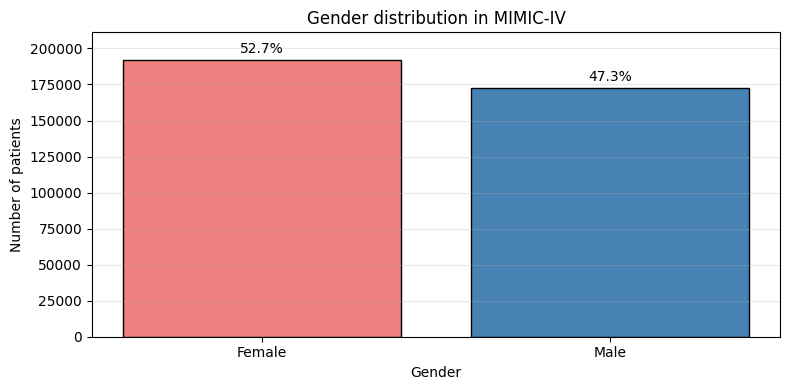

In [7]:
counts = demo["gender"].value_counts().reindex(["F", "M"])
labels = ["Female", "Male"]
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts.values, color=["lightcoral", "steelblue"], edgecolor="black")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in percentages], padding=3)
ax.set_xlabel("Gender")
ax.set_ylabel("Number of patients")
ax.set_title("Gender distribution in MIMIC-IV")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
save_fig("gender_distribution")
plt.show()

---
## - Age distribution plot

Age summary:
count    364627.0
mean         48.9
std          20.9
min          18.0
25%          29.0
50%          48.0
75%          65.0
max          91.0
Saved ./figures/age_distribution.png


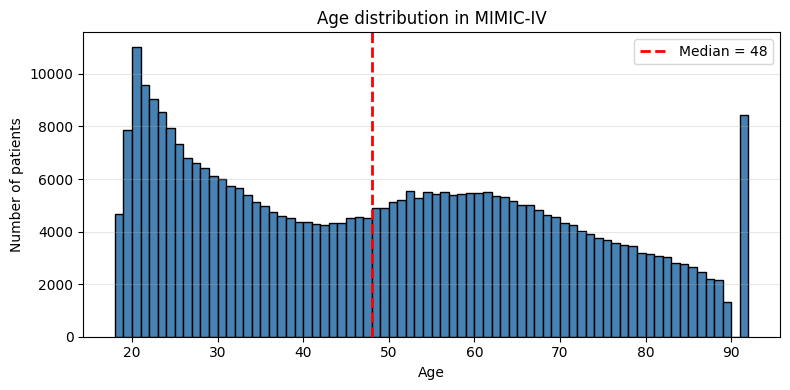

In [8]:
print("Age summary:")
print(demo["anchor_age"].describe().round(1).to_string())

median_age = demo["anchor_age"].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(demo["anchor_age"], bins=range(18, 93), color="steelblue", edgecolor="black")
ax.axvline(median_age,color="red",linestyle="--",linewidth=2, label=f"Median = {median_age:.0f}",)
ax.set_xlabel("Age")
ax.set_ylabel("Number of patients")
ax.set_title("Age distribution in MIMIC-IV")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
save_fig("age_distribution")
plt.show()

Anyone over 89 has their age set to 91 to prevent identification.

---
## - ICU stays exploration

In [9]:
icu = con.execute("""
    SELECT 
        icustays.stay_id, -- icu stay id
        icustays.subject_id, -- patient id
        icustays.hadm_id, -- hospital admission id
        icustays.first_careunit, -- icu type
        icustays.intime, -- icu admission time
        icustays.outtime, -- icu discharge time
        EXTRACT(EPOCH FROM (icustays.outtime - icustays.intime)) / 3600 AS los_hours
    FROM icu.icustays
""").df()

print(f"ICU stays: {len(icu):,}")
print(f"Unique patients with ICU stays: {icu['subject_id'].nunique():,}")

ICU stays: 94,458
Unique patients with ICU stays: 65,366


---
## - ICU length of stay plot

Length of stay (hours):
count    94444.0
mean        87.1
std        129.7
min          0.0
25%         26.3
50%         47.2
75%         92.7
max       5433.7
Saved ./figures/icu_los_distribution.png


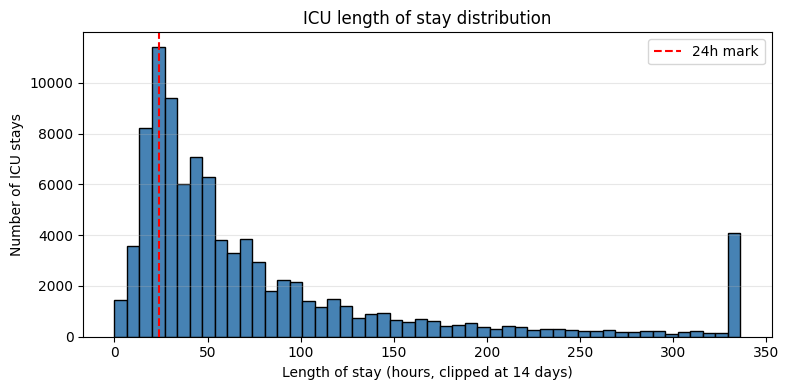

ICU stays of at least X hours long:
  >=    6h: 98.7%
  >=   12h: 95.8%
  >=   24h: 79.2%
  >=   48h: 49.1%
  >=   72h: 33.0%
  >=  168h: 11.8%


In [10]:
print("Length of stay (hours):")
print(icu["los_hours"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
# Clip at 14 days for visibility, longer stays are rare
ax.hist(icu["los_hours"].clip(upper=14 * 24), bins=50, color="steelblue", edgecolor="black")
ax.axvline(24, color="red", linestyle="--", label="24h mark")
ax.set_xlabel("Length of stay (hours, clipped at 14 days)")
ax.set_ylabel("Number of ICU stays")
ax.set_title("ICU length of stay distribution")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig("icu_los_distribution")
plt.show()

# Cumulative fraction by threshold
thresholds = [6, 12, 24, 48, 72, 168]
print("ICU stays of at least X hours long:")
for threshold in thresholds:
    percent = (icu["los_hours"] >= threshold).mean()
    print(f"  >= {threshold:>4}h: {percent:.1%}")

---
## - ICU care unit breakdown

In [11]:
careunits = icu["first_careunit"].value_counts()
print("ICU stays by care unit:")
print(careunits.to_string())

ICU stays by care unit:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                         10
Medicine/Cardiology Intermediate                        1
Med/Surg                                                1
Neurology                        

---
## - CAM-ICU items in d_items

In [12]:
# Find items related to CAM-ICU or delirium assessments
cam_items = con.execute("""
    SELECT
        itemid,
        label,
        category,
        param_type
    FROM icu.d_items
    WHERE LOWER(label) LIKE '%cam%'
        OR LOWER(label) LIKE '%delirium%'
        OR LOWER(label) LIKE '%assessment%'
    ORDER BY label
""").df()
print(f"Items: {len(cam_items)}")
print(cam_items.to_string(index=False))

Items: 32
 itemid                                             label                category param_type
 224003                              Abdominal Assessment                   GI/GU       Text
 228334                               CAM-ICU Altered LOC           Pain/Sedation       Text
 228303                     CAM-ICU Disorganized thinking           Pain/Sedation       Text
 229324                     CAM-ICU Disorganized thinking           Pain/Sedation       Text
 228335                     CAM-ICU Disorganized thinking           Pain/Sedation       Text
 229325                               CAM-ICU Inattention           Pain/Sedation       Text
 228301                               CAM-ICU Inattention           Pain/Sedation       Text
 228336                               CAM-ICU Inattention           Pain/Sedation       Text
 229326                                 CAM-ICU MS Change           Pain/Sedation       Text
 228337                                 CAM-ICU MS Change   

---
## - Inspect possibly relevant items

In [13]:
# Inspect actual values stored under CAM-ICU items
cam_values = con.execute("""
    SELECT 
        ce.itemid, 
        di.label,
        ce.value, 
        COUNT(*) AS n
    FROM icu.chartevents ce
    JOIN icu.d_items di ON ce.itemid = di.itemid
    WHERE di.itemid IN (228334, 228303, 229324, 228335, 229325, 228301, 228336, 229326, 228337, 228300, 228302, 228688, 228332)
    GROUP BY ce.itemid, di.label, ce.value
    ORDER BY di.label, n DESC
""").df()
print(cam_values.to_string(index=False))

 itemid                         label                                          value      n
 228334           CAM-ICU Altered LOC                                            Yes 107833
 228334           CAM-ICU Altered LOC                                             No  21223
 228303 CAM-ICU Disorganized thinking                                             No  15064
 229324 CAM-ICU Disorganized thinking                                            Yes   9628
 229324 CAM-ICU Disorganized thinking                                             No   3454
 228335 CAM-ICU Disorganized thinking                                            Yes   2304
 228335 CAM-ICU Disorganized thinking                                             No   1155
 228335 CAM-ICU Disorganized thinking                               Unable to Assess    821
 228303 CAM-ICU Disorganized thinking                                            Yes    319
 229325           CAM-ICU Inattention                                           

Item 228332 "Delirium assessment" is the only item with clean "Positive" / "Negative" / "UTA" values and it's the overall CAM-ICU result, not a sub-component.

---
## - Delirium assessment coverage in ICU stays

 stays_with_assessment  total_assessments
                 72944             610632
 stays_without_assessment
                    21514
Saved ./figures/cam_icu_coverage.png


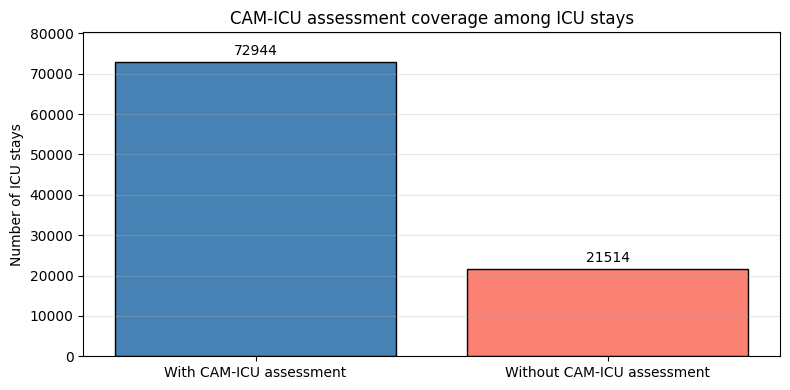

In [14]:
# Select distinct stays with at least one CAM-ICU assessment
coverage = con.execute("""
    SELECT 
        COUNT(DISTINCT stay_id) AS stays_with_assessment,
        COUNT(*) AS total_assessments
    FROM icu.chartevents
    WHERE itemid = 228332
""").df()
print(coverage.to_string(index=False))

# Select distinct stays without any CAM-ICU assessment
no_assessment = con.execute("""
    SELECT COUNT(*) AS stays_without_assessment
    FROM icu.icustays
    WHERE stay_id NOT IN (
        SELECT DISTINCT stay_id 
        FROM icu.chartevents 
        WHERE itemid = 228332
    )
""").df()
print(no_assessment.to_string(index=False))

labels = ["With CAM-ICU assessment", "Without CAM-ICU assessment"]
values = [coverage["stays_with_assessment"].iloc[0], no_assessment["stays_without_assessment"].iloc[0]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=["steelblue", "salmon"], edgecolor="black")
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of ICU stays")
ax.set_title("CAM-ICU assessment coverage among ICU stays")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
save_fig("cam_icu_coverage")
plt.show()

Out of 94,458 ICU stays, 21,514 have no delirium assessment at all. Without a delirium assessment, we can't label them and they cannot be in our cohort.

---
## - Delirium prevalence in assessable stays

Stays with at least one assessment: 72,944

Category breakdown:
category
only_negative    47417
ever_positive    22462
only_uta          3065
Saved ./figures/delirium_prevalence.png


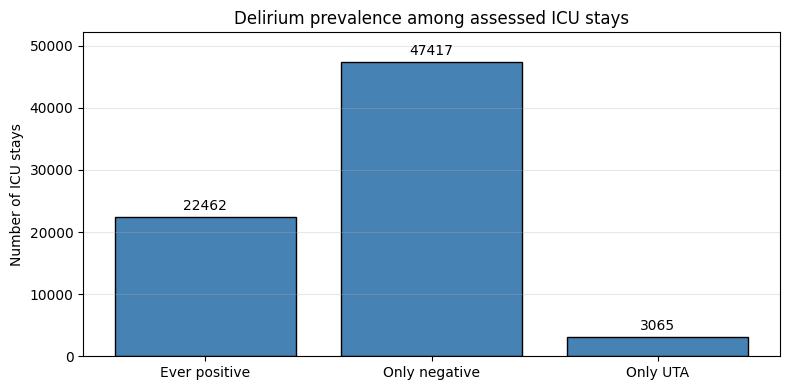

Percentages:
category
only_negative    0.650
ever_positive    0.308
only_uta         0.042


In [15]:
# For each stay that has assessments, classify as: ever positive, only negative, or only UTA
prevalence = con.execute("""
    SELECT 
        stay_id,
        SUM(CASE WHEN value = 'Positive' THEN 1 ELSE 0 END) AS n_positive,
        SUM(CASE WHEN value = 'Negative' THEN 1 ELSE 0 END) AS n_negative,
        SUM(CASE WHEN value = 'UTA' THEN 1 ELSE 0 END) AS n_uta
    FROM icu.chartevents
    WHERE itemid = 228332
    GROUP BY stay_id
""").df()

print(f"Stays with at least one assessment: {len(prevalence):,}")

# Categorise each stay
def categorise(row):
    if row["n_positive"] > 0:
        return "ever_positive"
    if row["n_negative"] > 0:
        return "only_negative"
    return "only_uta"

prevalence["category"] = prevalence.apply(categorise, axis=1)

print("\nCategory breakdown:")
print(prevalence["category"].value_counts().to_string())

labels = {
    "ever_positive": "Ever positive",
    "only_negative": "Only negative",
    "only_uta": "Only UTA"
}
values = prevalence["category"].value_counts().reindex(["ever_positive", "only_negative", "only_uta"]).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels.values(), values, color=["steelblue"], edgecolor="black")
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of ICU stays")
ax.set_title("Delirium prevalence among assessed ICU stays")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
save_fig("delirium_prevalence")
plt.show()

print("Percentages:")
print(prevalence["category"].value_counts(normalize=True).round(3).to_string())

The 3,065 UTA-only stays will need to be excluded because we have no usable label for them.

After excluding UTA-only stays, the split is 22,462 positive and 47,417 negative, which is 32% vs 68%, which is a moderate imbalance. This means we probably don't need SMOTE.

---
## - Timing of first positive delirium assessment plot

Timing summary:
count    22462.0
mean        32.0
std         82.9
min      -8659.8
25%          2.4
50%         12.9
75%         38.1
max       1321.9
Saved ./figures/delirium_onset_timing.png


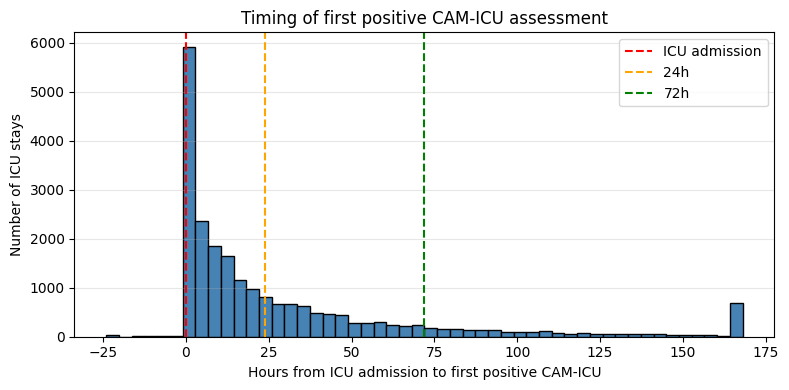

Fraction of first-positives within X hours of intime:
  <=    0h: 1.9%
  <=    6h: 35.3%
  <=   12h: 48.3%
  <=   24h: 64.2%
  <=   48h: 80.3%
  <=   72h: 87.7%
  <=  168h: 97.0%


In [25]:
# Select the first positive assessment time for each ever-positive stay
# Calculate hours from ICU intime to first positive assessment
timing = con.execute("""
    SELECT 
        chartevents.stay_id,
        icu.icustays.intime,
        MIN(chartevents.charttime) AS first_positive,
        EXTRACT(EPOCH FROM (MIN(chartevents.charttime) - icu.icustays.intime)) / 3600 AS hours_to_first_positive
    FROM icu.chartevents
    JOIN icu.icustays ON chartevents.stay_id = icu.icustays.stay_id
    WHERE chartevents.itemid = 228332 AND chartevents.value = 'Positive'
    GROUP BY chartevents.stay_id, icu.icustays.intime
""").df()

print("Timing summary:")
print(timing["hours_to_first_positive"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    timing["hours_to_first_positive"].clip(lower=-24, upper=168),
    bins=50,
    color="steelblue",
    edgecolor="black",
)
ax.axvline(0, color="red", linestyle="--", label="ICU admission")
ax.axvline(24, color="orange", linestyle="--", label="24h")
ax.axvline(72, color="green", linestyle="--", label="72h")
ax.set_xlabel("Hours from ICU admission to first positive CAM-ICU")
ax.set_ylabel("Number of ICU stays")
ax.set_title("Timing of first positive CAM-ICU assessment")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
save_fig("delirium_onset_timing")
plt.show()

# What fraction of first-positives occur before various thresholds?
print("Fraction of first-positives within X hours of intime:")
for threshold in [0, 6, 12, 24, 48, 72, 168]:
    percent = (timing["hours_to_first_positive"] <= threshold).mean()
    print(f"  <= {threshold:>4}h: {percent:.1%}")

---
## - Quantify pre-ICU positive assessments

In [26]:
# How many ever-positive stays have their first positive BEFORE ICU intime?
before_icu = (timing["hours_to_first_positive"] < 0).sum()
print(f"Stays with first positive before ICU intime: {before_icu:,}")

Stays with first positive before ICU intime: 409


Only 409 stays have a positive assessment before ICU intime. For our cohort definition we'll exclude these 409 stays.

---
## - Assessment frequency distribution plot

Assessment frequency summary:
count    72944.0
mean         8.4
std         12.3
min          1.0
25%          3.0
50%          5.0
75%          9.0
max        499.0

Time span between first and last assessment (hours):
count    72944.0
mean        77.1
std        158.6
min          0.0
25%         14.1
50%         36.0
75%         82.0
max       9224.0
Saved ./figures/assessment_frequency.png


C:\Users\Crazy\AppData\Local\Temp\ipykernel_41576\1389232948.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


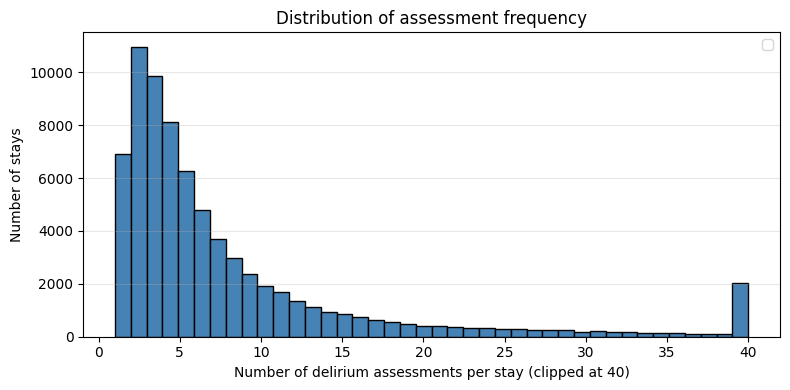

In [30]:
# Count delirium assessments per stay
# Calculate hours from first to last assessment for each stay
freq = con.execute("""
    SELECT 
        stay_id,
        COUNT(*) AS n_assessments,
        EXTRACT(EPOCH FROM (MAX(charttime) - MIN(charttime))) / 3600 AS hours_assessed_span
    FROM icu.chartevents
    WHERE itemid = 228332
    GROUP BY stay_id
""").df()

print("Assessment frequency summary:")
print(freq["n_assessments"].describe().round(1).to_string())

print("\nTime span between first and last assessment (hours):")
print(freq["hours_assessed_span"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    freq["n_assessments"].clip(upper=40),
    bins=40,
    color="steelblue",
    edgecolor="black",
)
ax.set_xlabel("Number of delirium assessments per stay (clipped at 40)")
ax.set_ylabel("Number of stays")
ax.set_title("Distribution of assessment frequency")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
save_fig("assessment_frequency")
plt.show()

---
## - Cohort size by LOS threshold plot

Saved ./figures/cohort_size_by_los_threshold.png


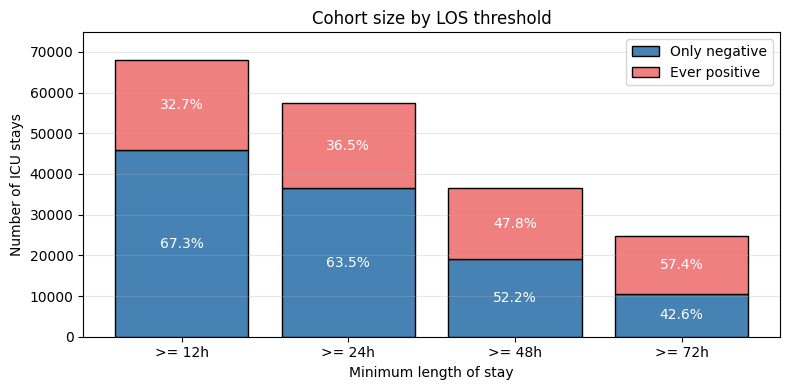

In [52]:
# Select ICU stays with their LOS and delirium category
los_filter = con.execute("""
    SELECT 
        icu.icustays.stay_id,
        EXTRACT(EPOCH FROM (icu.icustays.outtime - icu.icustays.intime)) / 3600 AS los_hours,
        CASE 
            WHEN d.ever_positive > 0 THEN 'ever_positive'
            WHEN d.ever_negative > 0 THEN 'only_negative'
            ELSE 'only_uta'
        END AS category
    FROM icu.icustays
    JOIN (
        SELECT
            stay_id,
            SUM(CASE WHEN value = 'Positive' THEN 1 ELSE 0 END) AS ever_positive,
            SUM(CASE WHEN value = 'Negative' THEN 1 ELSE 0 END) AS ever_negative
        FROM icu.chartevents
        WHERE itemid = 228332
        GROUP BY stay_id
    ) d ON icu.icustays.stay_id = d.stay_id
""").df()

# Calculate how many stays of each category are retained at each LOS threshold
thresholds = [12, 24, 48, 72]
pos_counts = []
neg_counts = []
for threshold in thresholds:
    kept = los_filter[los_filter["los_hours"] >= threshold]
    pos_counts.append((kept["category"] == "ever_positive").sum())
    neg_counts.append((kept["category"] == "only_negative").sum())

fig, ax = plt.subplots(figsize=(8, 4))
x_labels = [f">= {t}h" for t in thresholds]
bars_neg = ax.bar(
    x_labels, neg_counts, color="steelblue", edgecolor="black", label="Only negative"
)
bars_pos = ax.bar(
    x_labels,
    pos_counts,
    bottom=neg_counts,
    color="lightcoral",
    edgecolor="black",
    label="Ever positive",
)

# Percentage labels inside each segment
totals = [n + p for n, p in zip(neg_counts, pos_counts)]
neg_pcts = [n / t * 100 for n, t in zip(neg_counts, totals)]
pos_pcts = [p / t * 100 for p, t in zip(pos_counts, totals)]

ax.bar_label(
    bars_neg, labels=[f"{p:.1f}%" for p in neg_pcts], label_type="center", color="white"
)
ax.bar_label(
    bars_pos, labels=[f"{p:.1f}%" for p in pos_pcts], label_type="center", color="white"
)

ax.set_xlabel("Minimum length of stay")
ax.set_ylabel("Number of ICU stays")
ax.set_title("Cohort size by LOS threshold")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
ax.legend()
plt.tight_layout()
save_fig("cohort_size_by_los_threshold")
plt.show()

The 24h threshold retains the majority of delirium cases while ensuring enough temporal data for prediction and it doesn't bias the negative class as much as longer thresholds.

---
## - Cohort attrition plot

Saved ./figures/cohort_attrition.png


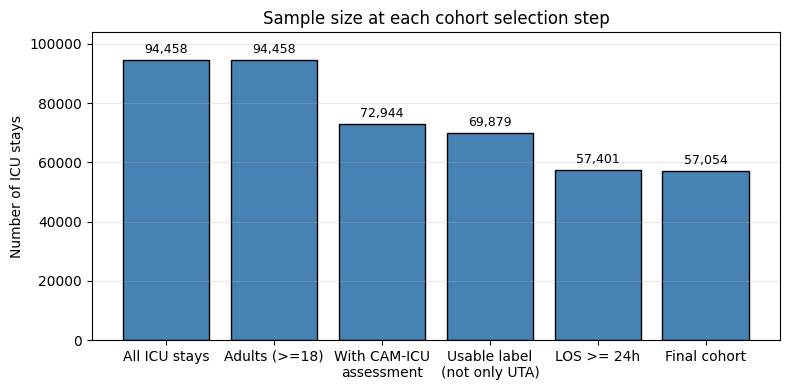

In [37]:
# Cohort definition based on what we've explored:
# - Adults (>=18)
# - At least one CAM-ICU assessment (itemid 228332)
# - At least one assessment that yielded a usable label (Positive or Negative, not only UTA)
# - ICU LOS of at least 24 hours
# - First positive (if any) occurred during the ICU stay, not before

# Count remaining stays at each filter step
steps = []

steps.append(
    (
        "All ICU stays",
        con.execute("""
    SELECT COUNT(*) FROM icu.icustays
""").fetchone()[0],
    )
)

steps.append(
    (
        "Adults (>=18)",
        con.execute("""
    SELECT COUNT(*)
    FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    WHERE p.anchor_age >= 18
""").fetchone()[0],
    )
)

steps.append(
    (
        "With CAM-ICU\nassessment",
        con.execute("""
    SELECT COUNT(*)
    FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    WHERE p.anchor_age >= 18
        AND i.stay_id IN (
            SELECT DISTINCT stay_id FROM icu.chartevents WHERE itemid = 228332
        )
""").fetchone()[0],
    )
)

steps.append(
    (
        "Usable label\n(not only UTA)",
        con.execute("""
    SELECT COUNT(*)
    FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    JOIN (
        SELECT stay_id, SUM(CASE WHEN value IN ('Positive', 'Negative') THEN 1 ELSE 0 END) AS n_usable
        FROM icu.chartevents WHERE itemid = 228332
        GROUP BY stay_id
    ) d ON i.stay_id = d.stay_id
    WHERE p.anchor_age >= 18 AND d.n_usable > 0
""").fetchone()[0],
    )
)

steps.append(
    (
        "LOS >= 24h",
        con.execute("""
    SELECT COUNT(*)
    FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    JOIN (
        SELECT stay_id, SUM(CASE WHEN value IN ('Positive', 'Negative') THEN 1 ELSE 0 END) AS n_usable
        FROM icu.chartevents WHERE itemid = 228332
        GROUP BY stay_id
    ) d ON i.stay_id = d.stay_id
    WHERE p.anchor_age >= 18
        AND d.n_usable > 0
        AND EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 >= 24
""").fetchone()[0],
    )
)

steps.append(("Final cohort", con.execute("SELECT COUNT(*) FROM cohort").fetchone()[0]))

labels, values = zip(*steps)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color="steelblue", edgecolor="black")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
ax.set_ylabel("Number of ICU stays")
ax.set_title("Sample size at each cohort selection step")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
save_fig("cohort_attrition")
plt.show()

---
## - Delirium vs non-delirium length of stay plot

Cohort: 57,054 stays
Saved ./figures/median_los_by_delirium.png


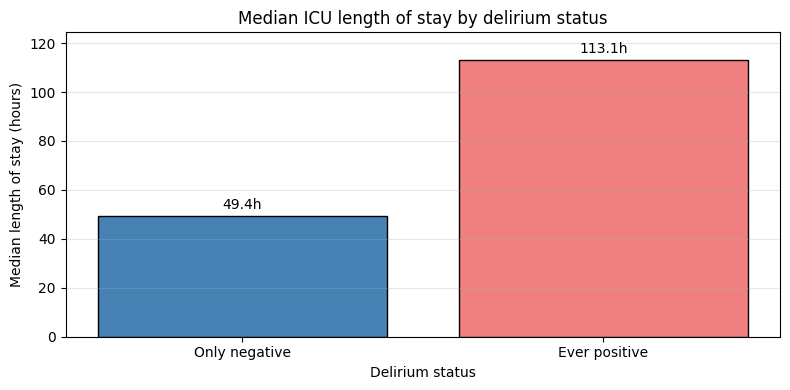

In [43]:
cohort_df = con.execute("SELECT * FROM cohort").df()
print(f"Cohort: {len(cohort_df):,} stays")

# Group by ever_delirious for comparison
summary = (
    cohort_df.groupby("ever_delirious")
    .agg(
        n_stays=("stay_id", "size"),
        n_patients=("subject_id", "nunique"),
        mean_age=("age", "mean"),
        median_age=("age", "median"),
        pct_female=("gender", lambda x: (x == "F").mean() * 100),
        median_los_h=("los_hours", "median"),
        mean_los_h=("los_hours", "mean"),
    )
    .round(1)
)

labels = {
    0: "Only negative",
    1: "Ever positive"
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    summary.index.map(labels),
    summary["median_los_h"],
    color=["steelblue", "lightcoral"],
    edgecolor="black",
)
ax.bar_label(bars, fmt="{:.1f}h", padding=3)
ax.set_xlabel("Delirium status")
ax.set_ylabel("Median length of stay (hours)")
ax.set_title("Median ICU length of stay by delirium status")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
save_fig("median_los_by_delirium")
plt.show()

Delirious patients' stays are nearly 2.3x longer in ICU as is confirmed in the literature.

## Care unit distribution by delirium status

In [27]:
careunit_breakdown = (
    cohort_df.groupby(["first_careunit", "ever_delirious"]).size().unstack(fill_value=0)
)
careunit_breakdown.columns = ["never_delirious", "ever_delirious"]
careunit_breakdown["total"] = careunit_breakdown.sum(axis=1)
careunit_breakdown["delirium_rate"] = (
    careunit_breakdown["ever_delirious"] / careunit_breakdown["total"] * 100
).round(1)
careunit_breakdown = careunit_breakdown.sort_values("total", ascending=False)
print("Delirium rate by ICU type:")
print(careunit_breakdown.to_string())

Delirium rate by ICU type:
                                                  never_delirious  ever_delirious  total  delirium_rate
first_careunit                                                                                         
Medical Intensive Care Unit (MICU)                           5596            5820  11416           51.0
Cardiac Vascular Intensive Care Unit (CVICU)                 8129            2142  10271           20.9
Medical/Surgical Intensive Care Unit (MICU/SICU)             5526            3102   8628           36.0
Surgical Intensive Care Unit (SICU)                          4438            2756   7194           38.3
Coronary Care Unit (CCU)                                     4726            1747   6473           27.0
Trauma SICU (TSICU)                                          3523            2305   5828           39.6
Neuro Intermediate                                           3312            1375   4687           29.3
Neuro Surgical Intensive Care Unit (N

---
## - Race distribution

In [44]:
race_breakdown = cohort_df["race"].value_counts().head(15)
print("Top 15 most common race categories in cohort:")
print(race_breakdown.to_string())

Top 15 most common race categories in cohort:
race
WHITE                             34367
UNKNOWN                            5952
BLACK/AFRICAN AMERICAN             5080
OTHER                              2171
WHITE - OTHER EUROPEAN             1690
UNABLE TO OBTAIN                    958
HISPANIC/LATINO - PUERTO RICAN      833
ASIAN - CHINESE                     675
WHITE - RUSSIAN                     641
ASIAN                               608
HISPANIC/LATINO - DOMINICAN         537
BLACK/CARIBBEAN ISLAND              410
BLACK/CAPE VERDEAN                  400
BLACK/AFRICAN                       300
PORTUGUESE                          292


---
## - Race consolidation

In [45]:
def simplify_race(r):
    if pd.isna(r):
        return "UNKNOWN"
    r = str(r).upper()
    if "WHITE" in r or "PORTUGUESE" in r:
        return "WHITE"
    if "BLACK" in r or "AFRICAN" in r:
        return "BLACK"
    if "HISPANIC" in r or "LATINO" in r or "SOUTH AMERICAN" in r:
        return "HISPANIC"
    if "ASIAN" in r:
        return "ASIAN"
    if "UNKNOWN" in r or "UNABLE" in r or "DECLINED" in r:
        return "UNKNOWN"
    return "OTHER"

cohort_df["race_simple"] = cohort_df["race"].apply(simplify_race)

---
## - Race distribution plot

Saved ./figures/race_distribution.png


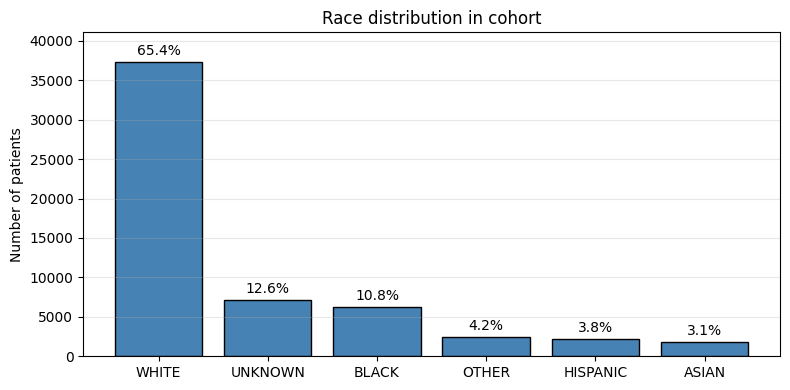

In [46]:
race_counts = cohort_df["race_simple"].value_counts()
race_pcts = race_counts / race_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    race_counts.index, race_counts.values, color="steelblue", edgecolor="black"
)
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in race_pcts], padding=3)
ax.set_ylabel("Number of patients")
ax.set_title("Race distribution in cohort")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
save_fig("race_distribution")
plt.show()

---
## - Save the cohort

In [47]:
cohort_df.to_parquet("./data/cohort.parquet", index=False, engine="pyarrow")
print(f"Saved cohort: {cohort_df.shape}")

Saved cohort: (57054, 16)


## Explore d_items for clinical concepts

In [31]:
# d_items lists every "item" that can appear in chartevents/inputevents/etc.
# Look at its structure first
d_items = con.execute("SELECT * FROM icu.d_items").df()
print(f"Total items in d_items: {len(d_items):,}")
print(f"\nColumns: {d_items.columns.tolist()}")
print("\nCategories (top 20 by count):")
print(d_items["category"].value_counts().head(20).to_string())

Total items in d_items: 4,095

Columns: ['itemid', 'label', 'abbreviation', 'linksto', 'category', 'unitname', 'param_type', 'lownormalvalue', 'highnormalvalue']

Categories (top 20 by count):
category
Skin - Impairment                     412
Access Lines - Invasive               372
Respiratory                           170
Labs                                  161
Medications                           139
Care Plans                            137
Skin - Incisions                      115
Nutrition - Enteral                   113
Ingredients - general (Not In Use)    109
Pain/Sedation                          97
Treatments                             93
Neurological                           88
Restraint/Support Systems              88
MD Progress Note                       85
Fluids - Other (Not In Use)            84
Access Lines - Peripheral              75
GI/GU                                  73
PA Line Insertion                      63
Bronchoscopy                           61


## Feature category selection: literature basis

Based on the literature reviewed, studies often use a small number of feature categories that are consistently informative:

- **Vital signs**: heart rate, blood pressure, respiratory rate, SpO2, and temperature are used in nearly all ICU delirium prediction studies (Gong et al., 2023; Park et al., 2025). They are charted frequently, capture acute physiological derangement, and several are independently associated with delirium onset.

- **Neurological assessments**: the Glasgow Coma Scale (GCS) was identified by Tang et al. (2024) as the single strongest predictor of delirium in elderly ICU patients. GCS measures level of consciousness directly, which is conceptually close to delirium itself.

- **Sedative and analgesic medications**: benzodiazepines, opioids, propofol, and dexmedetomidine are well-established risk factors. Tang et al. (2024) flagged sedation as a top predictor; Jauk et al. (2024) found medication records improved prediction performance. Antipsychotics (haloperidol) are sometimes included as they may reflect already-recognised agitation.

- **Routine laboratory results**: basic metabolic panel (sodium, potassium, BUN, creatinine, glucose), complete blood count (hemoglobin, WBC, platelets), and lactate are common in delirium prediction work because electrolyte disturbances, renal function, anaemia, and tissue hypoperfusion are known delirium triggers (Gong et al., 2023).

- **Demographics**: age and (where studied) gender and race. Age is the most consistently reported risk factor across systematic reviews (Wu et al., 2023; Ara et al., 2026).

## Items in vital sign and neurological categories

In [32]:
vital_items = con.execute("""
    SELECT itemid, label, category, unitname
    FROM icu.d_items
    WHERE category IN ('Routine Vital Signs', 'Neurological')
    ORDER BY category, label
""").df()

print(f"Items in vital sign and neurological categories: {len(vital_items)}")
print(vital_items.to_string(index=False))

Items in vital sign and neurological categories: 138
 itemid                                 label            category unitname
 226105                              Behavior        Neurological      NaN
 230152                                CFS-HR        Neurological      NaN
 230157                         CFS-Posturing        Neurological      NaN
 230153                                CFS-RR        Neurological      NaN
 230154                               CFS-SBP        Neurological      NaN
 230156                          CFS-Sweating        Neurological      NaN
 230155                              CFS-Temp        Neurological      NaN
 229386           Cerebellar - Finger -> Nose        Neurological      NaN
 229387             Cerebellar - Heel -> Shin        Neurological      NaN
 228398                              Commands        Neurological      NaN
 228397                     Commands Response        Neurological      NaN
 223903                         Communication  

### Measurement frequency for candidate vital items

In [33]:
# Candidate items based on label inspection: core vitals plus GCS plus consciousness
# This is a starting list; we'll verify usage frequency next
candidate_itemids = [
    # Heart rate
    220045,
    # Blood pressure: invasive arterial (2 itemid versions) + non-invasive
    220050,
    220051,
    220052,  # Arterial Blood Pressure
    225309,
    225310,
    225312,  # ART BP
    220179,
    220180,
    220181,  # Non Invasive BP
    # Respiratory
    220210,  # Respiratory Rate
    220277,  # SpO2
    # Temperature
    223761,
    223762,  # F and C
    # GCS components
    220739,
    223900,
    223901,  # Eye, Verbal, Motor
    # Consciousness
    226104,
]

# Count how many cohort stays have each item, and total measurement count
freq = con.execute(f"""
    SELECT 
        di.itemid,
        di.label,
        di.category,
        COUNT(*) AS n_measurements,
        COUNT(DISTINCT ce.stay_id) AS n_stays
    FROM icu.chartevents ce
    JOIN icu.d_items di ON ce.itemid = di.itemid
    WHERE ce.itemid IN ({','.join(str(i) for i in candidate_itemids)})
      AND ce.stay_id IN (SELECT stay_id FROM cohort)
    GROUP BY di.itemid, di.label, di.category
    ORDER BY n_measurements DESC
""").df()

# Add coverage as fraction of cohort
n_cohort = len(cohort_df)
freq["coverage_pct"] = (freq["n_stays"] / n_cohort * 100).round(1)
print(freq.to_string(index=False))

 itemid                                 label            category  n_measurements  n_stays  coverage_pct
 220045                            Heart Rate Routine Vital Signs         6542439    57054         100.0
 220210                      Respiratory Rate         Respiratory         6448084    57016          99.9
 220277           O2 saturation pulseoxymetry         Respiratory         6412903    57046         100.0
 220179  Non Invasive Blood Pressure systolic Routine Vital Signs         4066935    56642          99.3
 220180 Non Invasive Blood Pressure diastolic Routine Vital Signs         4066427    56637          99.3
 220181      Non Invasive Blood Pressure mean Routine Vital Signs         4059573    56682          99.3
 220052          Arterial Blood Pressure mean Routine Vital Signs         2225434    24252          42.5
 220050      Arterial Blood Pressure systolic Routine Vital Signs         2220129    24124          42.3
 220051     Arterial Blood Pressure diastolic Routine V

### Vital feature selection

Based on measurement frequency in our cohort, we select the following vital signs as features:

| Feature | Itemid(s) | Cohort coverage |
|---------|-----------|-----------------|
| Heart rate | 220045 | 100% |
| Respiratory rate | 220210 | 99.9% |
| SpO2 | 220277 | 100% |
| Systolic BP | 220050 (arterial), 220179 (non-invasive), 225309 (ART) | 99.3% via non-invasive, 42.5% via arterial |
| Diastolic BP | 220051, 220180, 225310 | as above |
| Mean BP | 220052, 220181, 225312 | as above |
| Temperature | 223761 (F), 223762 (C) | 99.5% via F, 12.2% via C |
| GCS Eye | 220739 | 100% |
| GCS Verbal | 223900 | 100% |
| GCS Motor | 223901 | 100% |

For blood pressure, we coalesce arterial and non-invasive sources (arterial is more accurate for the patients who have invasive lines; non-invasive cuff readings serve as a fallback). For temperature, we convert Fahrenheit to Celsius during aggregation since Fahrenheit is the dominant source. We exclude Level of Consciousness (itemid 226104) because of low coverage (4.1%) and exclude other neurological items in the d_items category for the same reason.

### Sample raw vital values for distribution inspection

In [34]:
# Itemid mapping for the candidate vitals we picked
VITAL_ITEMIDS = {
    "heart_rate": [220045],
    "resp_rate": [220210],
    "spo2": [220277],
    "sbp_arterial": [220050, 225309],
    "sbp_noninvasive": [220179],
    "temp_fahrenheit": [223761],
    "temp_celsius": [223762],
    "gcs_eye": [220739],
    "gcs_verbal": [223900],
    "gcs_motor": [223901],
}

# Pull a sample of raw values per vital
all_vital_ids = [i for ids in VITAL_ITEMIDS.values() for i in ids]
all_vital_ids_str = ",".join(str(i) for i in all_vital_ids)

# Pull a real sample by limiting after filtering, not before
raw_vitals_list = []
for vital_name, itemids in VITAL_ITEMIDS.items():
    ids_str = ",".join(str(i) for i in itemids)
    df = con.execute(f"""
        SELECT 
            {itemids[0]} AS first_itemid,
            '{vital_name}' AS vital_name,
            valuenum AS value
        FROM icu.chartevents
        WHERE itemid IN ({ids_str})
          AND valuenum IS NOT NULL
          AND stay_id IN (SELECT stay_id FROM cohort)
        ORDER BY RANDOM()
        LIMIT 500000
    """).df()
    raw_vitals_list.append(df)

raw_vitals = pd.concat(raw_vitals_list, ignore_index=True)
print(f"Total sampled rows: {len(raw_vitals):,}")
print("\nRange per vital:")
print(
    raw_vitals.groupby("vital_name")["value"]
    .describe()
    .round(1)[["count", "min", "25%", "50%", "75%", "max"]]
    .to_string()
)

Total sampled rows: 4,814,793

Range per vital:
                    count       min    25%    50%    75%        max
vital_name                                                         
gcs_eye          500000.0       1.0    3.0    4.0    4.0        4.0
gcs_motor        500000.0       1.0    5.0    6.0    6.0        6.0
gcs_verbal       500000.0       1.0    1.0    4.0    5.0        5.0
heart_rate       500000.0       0.0   73.0   85.0   98.0   102115.0
resp_rate        500000.0       0.0   16.0   20.0   24.0  7000400.0
sbp_arterial     500000.0     -15.0  102.0  116.0  132.0      357.0
sbp_noninvasive  500000.0       0.0  103.0  117.0  134.0    15092.0
spo2             500000.0 -951234.0   95.0   97.0   99.0  9765430.0
temp_celsius     314793.0       0.0   36.5   37.0   37.5     3467.0
temp_fahrenheit  500000.0       0.0   98.0   98.4   99.0     1000.0


### Distribution plots for each vital

Saved ./figures/vital_distributions.png


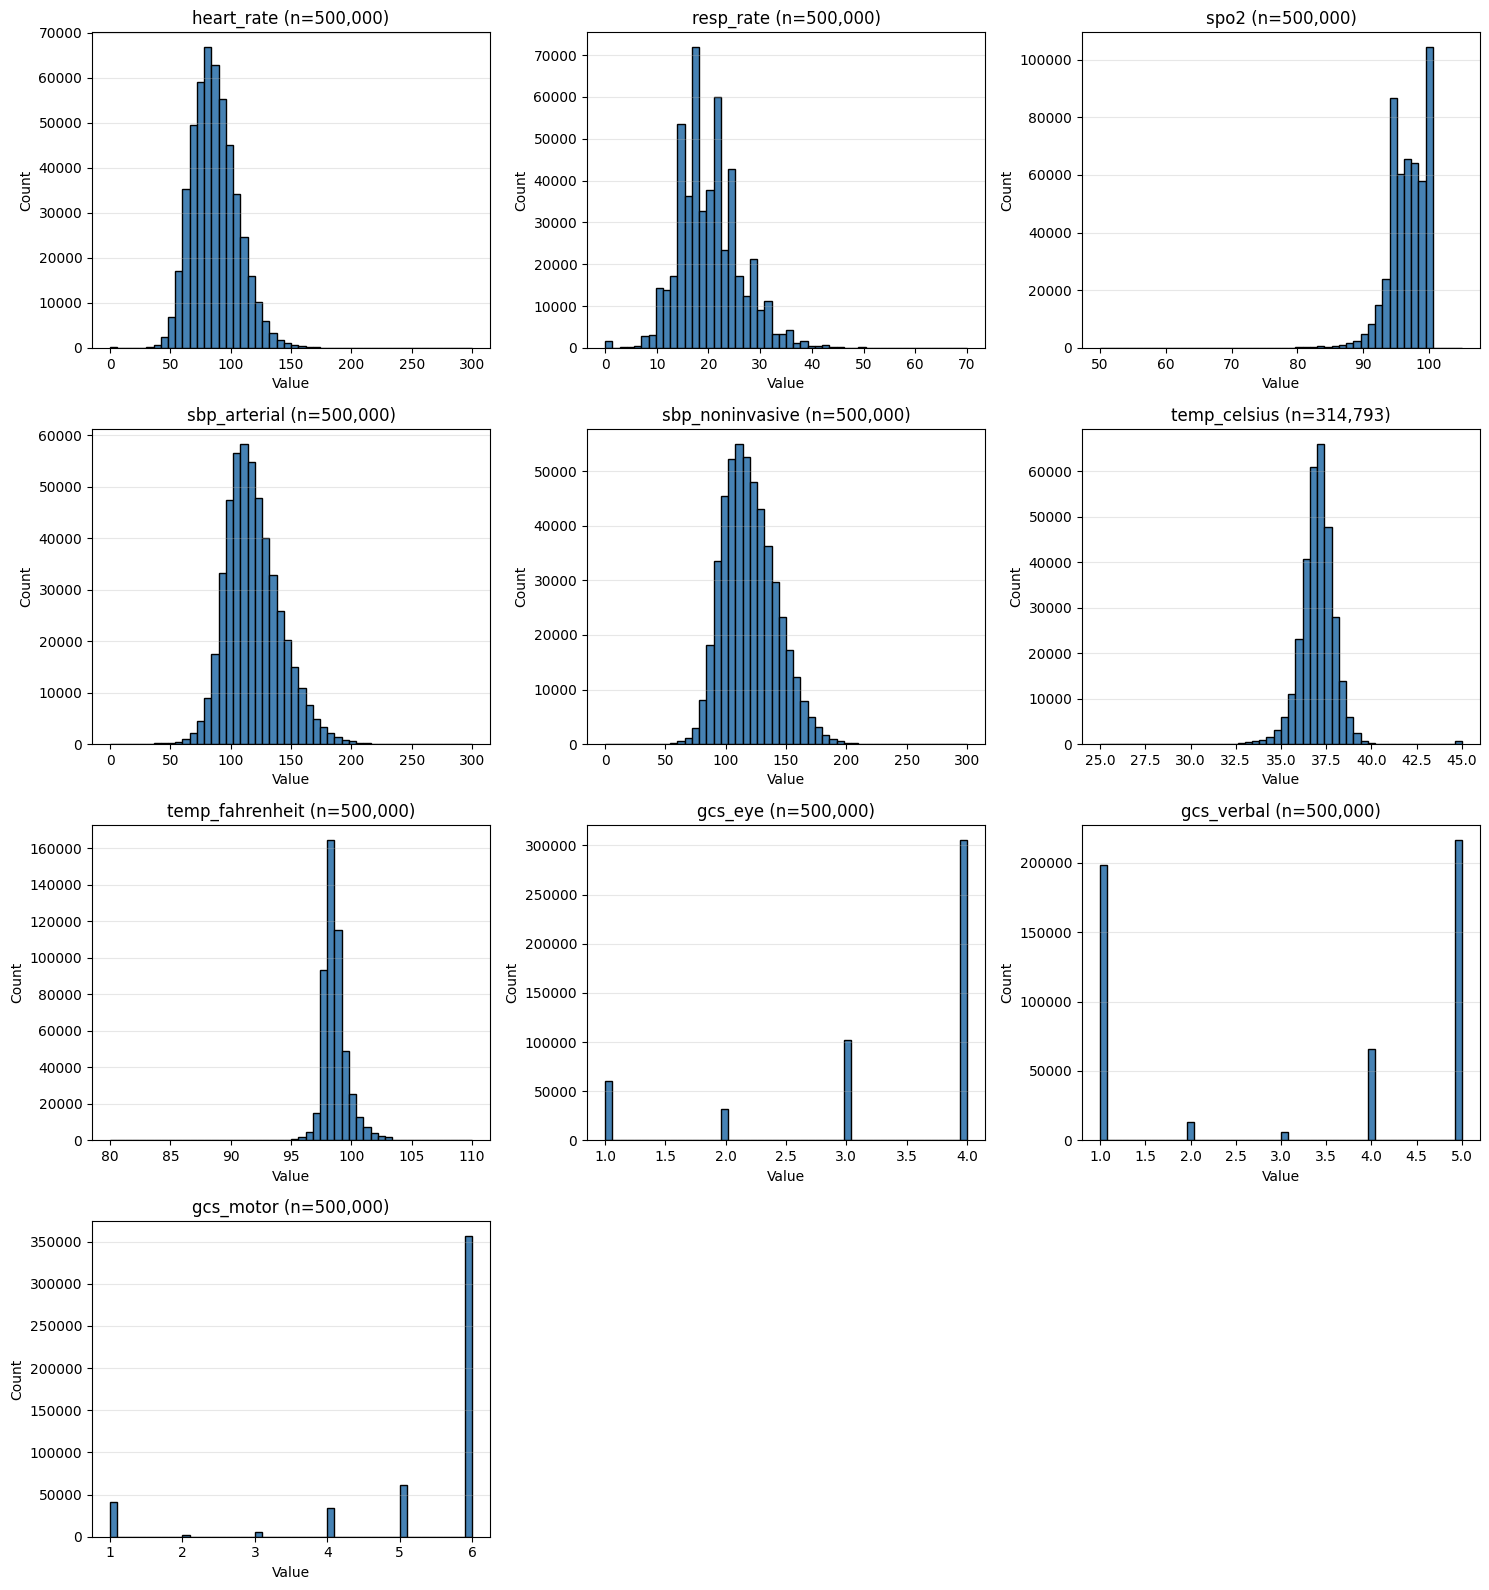

In [35]:
# Set up the figure: 3 columns, enough rows for all vitals
vitals_to_plot = [
    "heart_rate",
    "resp_rate",
    "spo2",
    "sbp_arterial",
    "sbp_noninvasive",
    "temp_celsius",
    "temp_fahrenheit",
    "gcs_eye",
    "gcs_verbal",
    "gcs_motor",
]

# Sensible plot ranges (wide enough to show outliers approaching the edge)
plot_ranges = {
    "heart_rate": (0, 300),
    "resp_rate": (0, 70),
    "spo2": (50, 105),
    "sbp_arterial": (0, 300),
    "sbp_noninvasive": (0, 300),
    "temp_celsius": (25, 45),
    "temp_fahrenheit": (80, 110),
    "gcs_eye": (0, 5),
    "gcs_verbal": (0, 6),
    "gcs_motor": (0, 7),
}

n_cols = 3
n_rows = (len(vitals_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, vital in enumerate(vitals_to_plot):
    ax = axes[i]
    values = raw_vitals[raw_vitals["vital_name"] == vital]["value"]
    low, high = plot_ranges[vital]
    clipped = values.clip(low, high)
    ax.hist(clipped, bins=50, color="steelblue", edgecolor="black")
    ax.set_title(f"{vital} (n={len(values):,})")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

# Hide unused subplots
for i in range(len(vitals_to_plot), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
save_fig("vital_distributions")
plt.show()

### Range filtering justification

Inspection of the value distributions revealed clear data quality issues: a small number of measurements take physiologically impossible values (e.g., heart rate over 100,000 bpm, SpO2 over 900,000%, temperature over 230°F). These are likely data entry errors or sensor malfunctions. Including them would corrupt downstream aggregations (means and standard deviations).

We apply physiological range filters based on the value distributions and clinical knowledge. The filters are loose enough to retain all real extreme measurements (e.g., severe tachycardia, hypothermia, hypotension) but tight enough to exclude obvious errors:

| Vital | Valid range | Rationale |
|-------|-------------|-----------|
| Heart rate | 20-300 bpm | Below 20 is asystolic/non-viable; above 300 is impossible |
| Respiratory rate | 0-70 | Apnea to extreme tachypnea |
| SpO2 | 50-100 % | Below 50% is barely compatible with life; ceiling at 100% |
| Systolic BP | 30-300 mmHg | Severe shock to hypertensive crisis |
| Diastolic BP | 10-200 mmHg | Same |
| Mean BP | 20-250 mmHg | Same |
| Temperature | 25-45 °C | Survivable hypothermia to extreme hyperthermia |
| GCS Eye | 1-4 | Scale-bounded |
| GCS Verbal | 1-5 | Scale-bounded |
| GCS Motor | 1-6 | Scale-bounded |

Out-of-range values are dropped before windowed aggregation.


### Extract vital events with range filtering

In [36]:
# Build the full itemid list for the extraction
all_vital_ids = []
for ids in VITAL_ITEMIDS.values():
    all_vital_ids.extend(ids)
all_vital_ids_str = ",".join(str(i) for i in all_vital_ids)

# Itemids that represent the same vital from different sources (for consolidation)
SBP_IDS = "220050, 220179, 225309"
DBP_IDS = "220051, 220180, 225310"
MBP_IDS = "220052, 220181, 225312"
HR_IDS = "220045"
RR_IDS = "220210"
SPO2_IDS = "220277"
TEMP_F_IDS = "223761"
TEMP_C_IDS = "223762"
GCS_EYE_IDS = "220739"
GCS_VERBAL_IDS = "223900"
GCS_MOTOR_IDS = "223901"

# Note: we add diastolic BP, mean BP, and other variants to VITAL_ITEMIDS too
VITAL_ITEMIDS = {
    "heart_rate": [220045],
    "sbp": [220050, 220179, 225309],
    "dbp": [220051, 220180, 225310],
    "mbp": [220052, 220181, 225312],
    "resp_rate": [220210],
    "spo2": [220277],
    "temp_f": [223761],
    "temp_c": [223762],
    "gcs_eye": [220739],
    "gcs_verbal": [223900],
    "gcs_motor": [223901],
}

# Recompute the flat list since we expanded the dict
all_vital_ids = []
for ids in VITAL_ITEMIDS.values():
    all_vital_ids.extend(ids)
all_vital_ids_str = ",".join(str(i) for i in all_vital_ids)

# Build a CASE expression: maps each itemid -> vital_name
case_lines = []
for vital_name, itemids in VITAL_ITEMIDS.items():
    ids = ",".join(str(i) for i in itemids)
    case_lines.append(f"WHEN ce.itemid IN ({ids}) THEN '{vital_name}'")
vital_case = "CASE " + " ".join(case_lines) + " END"

# Extract events; convert F to C in the same pass
con.execute(f"""
    CREATE OR REPLACE TABLE vital_events AS
    SELECT
        ce.stay_id,
        ce.charttime,
        {vital_case} AS vital_name,
        CASE 
            WHEN ce.itemid = {TEMP_F_IDS} THEN (ce.valuenum - 32) * 5.0 / 9.0
            ELSE ce.valuenum
        END AS value
    FROM icu.chartevents ce
    WHERE ce.stay_id IN (SELECT stay_id FROM cohort)
      AND ce.itemid IN ({all_vital_ids_str})
      AND ce.valuenum IS NOT NULL
""")

# Merge temp_f (converted) and temp_c into a single 'temperature' vital
con.execute("""
    UPDATE vital_events 
    SET vital_name = 'temperature'
    WHERE vital_name IN ('temp_f', 'temp_c')
""")

# Apply physiological range filters
con.execute("""
    DELETE FROM vital_events
    WHERE (vital_name = 'heart_rate' AND (value < 20 OR value > 300))
       OR (vital_name = 'sbp' AND (value < 30 OR value > 300))
       OR (vital_name = 'dbp' AND (value < 10 OR value > 200))
       OR (vital_name = 'mbp' AND (value < 20 OR value > 250))
       OR (vital_name = 'resp_rate' AND (value < 0 OR value > 70))
       OR (vital_name = 'spo2' AND (value < 50 OR value > 100))
       OR (vital_name = 'temperature' AND (value < 25 OR value > 45))
""")

n_windows = con.execute("SELECT COUNT(*) FROM vital_events").fetchone()[0]
print(f"Vital events after extraction and filtering: {n_windows:,}")

# Show how many got dropped per vital due to range filtering
# (we can't easily get this without re-running, so just show the resulting counts)
counts = con.execute("""
    SELECT vital_name, COUNT(*) AS n_events,
           ROUND(MIN(value), 1) AS min_value,
           ROUND(MAX(value), 1) AS max_value
    FROM vital_events
    GROUP BY vital_name
    ORDER BY n_events DESC
""").df()
print(counts.to_string(index=False))

Vital events after extraction and filtering: 45,899,678
 vital_name  n_events  min_value  max_value
        sbp   6584236       30.0      300.0
        dbp   6583375       10.0      200.0
        mbp   6574830       20.0      250.0
 heart_rate   6540641       20.0      300.0
  resp_rate   6447547        0.0       70.0
       spo2   6411267       50.0      100.0
temperature   1854113       25.0       44.8
    gcs_eye   1637902        1.0        4.0
 gcs_verbal   1635311        1.0        5.0
  gcs_motor   1630456        1.0        6.0


## Items in d_labitems

In [37]:
d_labitems = con.execute("SELECT * FROM hosp.d_labitems").df()
print(f"Total lab items: {len(d_labitems):,}")
print("\nCategories:")
print(d_labitems["category"].value_counts().to_string())
print("\nFluids:")
print(d_labitems["fluid"].value_counts().head(10).to_string())

Total lab items: 1,650

Categories:
category
Chemistry     800
Hematology    785
Blood Gas      65

Fluids:
fluid
Blood                  821
Other Body Fluid       201
Urine                  194
Cerebrospinal Fluid    101
Joint Fluid             72
Pleural                 69
Ascites                 68
Bone Marrow             63
Stool                   46
Q                        9


### Find candidate lab itemids

For delirium prediction we focus on blood-based labs only, dropping urine, CSF, joint fluid, etc., since those are specialised tests with low coverage and the literature doesn't use them.

Following the literature (Gong et al., Tang et al., Jauk et al.), the canonical "basic metabolic + CBC + lactate" panel is:
- Electrolytes: sodium, potassium, chloride, bicarbonate
- Renal: BUN, creatinine
- Metabolic: glucose
- Hematology: hemoglobin, hematocrit, WBC, platelets
- Perfusion: lactate

In [38]:
lab_keywords = {
    "sodium": "%sodium%",
    "potassium": "%potassium%",
    "chloride": "%chloride%",
    "bicarbonate": "%bicarbonate%",
    "bun": "%urea nitrogen%",
    "creatinine": "%creatinine%",
    "glucose": "%glucose%",
    "hemoglobin": "%hemoglobin%",
    "hematocrit": "%hematocrit%",
    "wbc": "%white blood%",
    "platelets": "%platelet count%",
    "lactate": "%lactate%",
}

for lab_name, keyword in lab_keywords.items():
    print(f"\n{lab_name.upper()}:")
    matches = con.execute(f"""
        SELECT itemid, label, category, fluid
        FROM hosp.d_labitems
        WHERE LOWER(label) LIKE '{keyword}'
          AND fluid = 'Blood'
        ORDER BY itemid
    """).df()
    print(matches.to_string(index=False))


SODIUM:
 itemid               label  category fluid
  50824 Sodium, Whole Blood Blood Gas Blood
  50983              Sodium Chemistry Blood
  52455 Sodium, Whole Blood Blood Gas Blood
  52623              Sodium Chemistry Blood

POTASSIUM:
 itemid                  label  category fluid
  50822 Potassium, Whole Blood Blood Gas Blood
  50971              Potassium Chemistry Blood
  52452 Potassium, Whole Blood Blood Gas Blood
  52610              Potassium Chemistry Blood

CHLORIDE:
 itemid                 label  category fluid
  50806 Chloride, Whole Blood Blood Gas Blood
  50902              Chloride Chemistry Blood
  52434 Chloride, Whole Blood Blood Gas Blood
  52535              Chloride Chemistry Blood

BICARBONATE:
 itemid                               label  category fluid
  50803 Calculated Bicarbonate, Whole Blood Blood Gas Blood
  50882                         Bicarbonate Chemistry Blood

BUN:
 itemid         label  category fluid
  51006 Urea Nitrogen Chemistry Blood
  52647

### Measurement frequency for candidate lab itemids

In [39]:
# Candidate itemids, grouped by lab
candidate_lab_ids = {
    "sodium": [50983, 50824, 52455, 52623],
    "potassium": [50971, 50822, 52452, 52610],
    "chloride": [50902, 50806, 52434, 52535],
    "bicarbonate": [50882, 50803],
    "bun": [51006, 52647],
    "creatinine": [50912, 52024, 52546],
    "glucose": [50931, 50809, 52027, 52569],
    "hemoglobin": [51222, 50811, 51640, 50855, 51645],
    "hematocrit": [51221, 50810, 51638, 51639, 52028],
    "wbc": [51301, 51755, 51756],
    "platelets": [51265, 53189],
    "lactate": [50813, 52442, 53154],
}

# Get coverage per itemid
all_lab_ids = []
for ids in candidate_lab_ids.values():
    all_lab_ids.extend(ids)
all_lab_ids_str = ",".join(str(i) for i in all_lab_ids)

freq = con.execute(f"""
    SELECT 
        dl.itemid,
        dl.label,
        dl.category,
        COUNT(*) AS n_measurements,
        COUNT(DISTINCT le.hadm_id) AS n_admissions
    FROM hosp.labevents le
    JOIN hosp.d_labitems dl ON le.itemid = dl.itemid
    WHERE le.itemid IN ({all_lab_ids_str})
      AND le.hadm_id IN (SELECT DISTINCT hadm_id FROM cohort)
    GROUP BY dl.itemid, dl.label, dl.category
    ORDER BY n_measurements DESC
""").df()

n_cohort_adm = con.execute("SELECT COUNT(DISTINCT hadm_id) FROM cohort").fetchone()[0]
freq["coverage_pct"] = (freq["n_admissions"] / n_cohort_adm * 100).round(1)
print(freq.to_string(index=False))

 itemid                               label   category  n_measurements  n_admissions  coverage_pct
  50971                           Potassium  Chemistry          848167         52060          99.7
  50983                              Sodium  Chemistry          846325         52060          99.7
  50902                            Chloride  Chemistry          833687         52059          99.7
  50912                          Creatinine  Chemistry          814312         52060          99.7
  51006                       Urea Nitrogen  Chemistry          812329         52058          99.7
  50882                         Bicarbonate  Chemistry          809812         52057          99.7
  50931                             Glucose  Chemistry          797610         52056          99.7
  51221                          Hematocrit Hematology          793514         52042          99.7
  51265                      Platelet Count Hematology          757314         52044          99.7
  51222   

### Lab feature selection

Based on measurement frequency in our cohort, we select the following labs as features. For each lab we use the dominant Chemistry itemid (~99.7% of cohort admissions). Lactate is the exception: it is not part of routine Chemistry panels and is drawn primarily through Blood Gas workflows (73.6% coverage).

| Feature | Itemid | Category | Cohort coverage |
|---------|--------|----------|-----------------|
| Sodium | 50983 | Chemistry | 99.7% |
| Potassium | 50971 | Chemistry | 99.7% |
| Chloride | 50902 | Chemistry | 99.7% |
| Bicarbonate | 50882 | Chemistry | 99.7% |
| BUN (Urea Nitrogen) | 51006 | Chemistry | 99.7% |
| Creatinine | 50912 | Chemistry | 99.7% |
| Glucose | 50931 | Chemistry | 99.7% |
| Hemoglobin | 51222 | Hematology | 99.7% |
| Hematocrit | 51221 | Hematology | 99.7% |
| WBC | 51301 | Hematology | 99.7% |
| Platelets | 51265 | Hematology | 99.7% |
| Lactate | 50813 | Blood Gas | 73.6% |

These cover the basic metabolic panel (electrolytes, BUN, creatinine, glucose), CBC (hemoglobin, hematocrit, WBC, platelets), and lactate (perfusion). Blood Gas duplicates of routine labs (e.g., sodium via ABG) were excluded since they cover only ~35-45% of admissions and the Chemistry version is already near-universal.

The lower coverage for lactate (73.6%) reflects clinical practice: lactate is drawn when shock, sepsis, or hypoperfusion is suspected, not routinely. The "absence of a lactate measurement" carries information (the clinical team did not think it was needed), which we will capture later through a missingness indicator.


### Sample raw lab values for distribution inspection

In [40]:
LAB_ITEMIDS = {
    "sodium": [50983],
    "potassium": [50971],
    "chloride": [50902],
    "bicarbonate": [50882],
    "bun": [51006],
    "creatinine": [50912],
    "glucose": [50931],
    "hemoglobin": [51222],
    "hematocrit": [51221],
    "wbc": [51301],
    "platelets": [51265],
    "lactate": [50813],
}

# Sample raw values per lab; use the proper LIMIT-after-filter pattern
raw_labs_list = []
for lab_name, itemids in LAB_ITEMIDS.items():
    ids_str = ",".join(str(i) for i in itemids)
    df = con.execute(f"""
        SELECT 
            '{lab_name}' AS lab_name,
            valuenum AS value
        FROM hosp.labevents
        WHERE itemid IN ({ids_str})
          AND valuenum IS NOT NULL
          AND hadm_id IN (SELECT DISTINCT hadm_id FROM cohort)
        ORDER BY RANDOM()
        LIMIT 50000
    """).df()
    raw_labs_list.append(df)

raw_labs = pd.concat(raw_labs_list, ignore_index=True)

print("Range per lab:")
print(
    raw_labs.groupby("lab_name")["value"]
    .describe()
    .round(2)[["count", "min", "25%", "50%", "75%", "max"]]
    .to_string()
)

Range per lab:
               count   min    25%    50%    75%        max
lab_name                                                  
bicarbonate  50000.0   4.0   22.0   25.0   28.0       50.0
bun          50000.0   1.0   14.0   23.0   40.0      243.0
chloride     50000.0  59.0   98.0  102.0  106.0      140.0
creatinine   50000.0   0.0    0.7    1.0    1.7       33.1
glucose      50000.0  11.0  101.0  123.0  156.0     3260.0
hematocrit   50000.0   4.4   25.1   28.4   32.9       62.8
hemoglobin   50000.0   2.0    8.0    9.1   10.7       19.3
lactate      50000.0   0.0    1.2    1.8    2.7  1276103.0
platelets    50000.0   5.0  120.0  191.0  278.0     2385.0
potassium    50000.0   1.5    3.7    4.1    4.5       14.1
sodium       50000.0  85.0  135.0  138.0  142.0      180.0
wbc          50000.0   0.1    7.0    9.8   13.7      398.3


### Lab range filtering justification

Lab value ranges were chosen based on the observed distributions and standard clinical reference ranges. Values outside the survival range or at physiological impossibilities (creatinine = 0, lactate = 0, sodium = 67) are excluded as data entry errors:

| Lab | Valid range | Unit |
|-----|-------------|------|
| Sodium | 100-180 | mmol/L |
| Potassium | 1-10 | mmol/L |
| Chloride | 70-140 | mmol/L |
| Bicarbonate | 5-50 | mmol/L |
| BUN | 1-300 | mg/dL |
| Creatinine | 0.1-30 | mg/dL |
| Glucose | 10-2000 | mg/dL |
| Hemoglobin | 2-25 | g/dL |
| Hematocrit | 5-75 | % |
| WBC | 0.1-500 | K/uL |
| Platelets | 5-2000 | K/uL |
| Lactate | 0.1-40 | mmol/L |

These ranges are loose enough to retain legitimate medical extremes (severe DKA, severe shock, leukemia) but exclude values that are biologically impossible.

### Extract lab events with range filtering

In [41]:
# Build the itemid -> lab_name CASE expression
case_lines = []
for lab_name, itemids in LAB_ITEMIDS.items():
    ids = ",".join(str(i) for i in itemids)
    case_lines.append(f"WHEN le.itemid IN ({ids}) THEN '{lab_name}'")
lab_case = "CASE " + " ".join(case_lines) + " END"

all_lab_ids = []
for ids in LAB_ITEMIDS.values():
    all_lab_ids.extend(ids)
all_lab_ids_str = ",".join(str(i) for i in all_lab_ids)

# Extract events for cohort admissions
con.execute(f"""
    CREATE OR REPLACE TABLE lab_events AS
    SELECT
        le.hadm_id,
        le.charttime,
        {lab_case} AS lab_name,
        le.valuenum AS value
    FROM hosp.labevents le
    WHERE le.hadm_id IN (SELECT DISTINCT hadm_id FROM cohort)
      AND le.itemid IN ({all_lab_ids_str})
      AND le.valuenum IS NOT NULL
""")

# Apply physiological range filters
con.execute("""
    DELETE FROM lab_events
    WHERE (lab_name = 'sodium' AND (value < 100 OR value > 180))
       OR (lab_name = 'potassium' AND (value < 1 OR value > 10))
       OR (lab_name = 'chloride' AND (value < 70 OR value > 140))
       OR (lab_name = 'bicarbonate' AND (value < 5 OR value > 50))
       OR (lab_name = 'bun' AND (value < 1 OR value > 300))
       OR (lab_name = 'creatinine' AND (value < 0.1 OR value > 30))
       OR (lab_name = 'glucose' AND (value < 10 OR value > 2000))
       OR (lab_name = 'hemoglobin' AND (value < 2 OR value > 25))
       OR (lab_name = 'hematocrit' AND (value < 5 OR value > 75))
       OR (lab_name = 'wbc' AND (value < 0.1 OR value > 500))
       OR (lab_name = 'platelets' AND (value < 5 OR value > 2000))
       OR (lab_name = 'lactate' AND (value < 0.1 OR value > 40))
""")

n_windows = con.execute("SELECT COUNT(*) FROM lab_events").fetchone()[0]
print(f"Lab events after extraction and filtering: {n_windows:,}")

counts = con.execute("""
    SELECT lab_name, COUNT(*) AS n_events,
           ROUND(MIN(value), 2) AS min_value,
           ROUND(MAX(value), 2) AS max_value
    FROM lab_events
    GROUP BY lab_name
    ORDER BY n_events DESC
""").df()
print(counts.to_string(index=False))

Lab events after extraction and filtering: 9,090,245
   lab_name  n_events  min_value  max_value
  potassium    847518        1.0       10.0
     sodium    846145      100.0      180.0
   chloride    833414       70.0      140.0
 creatinine    813532        0.1       29.8
        bun    811699        1.0      291.0
bicarbonate    809446        5.0       50.0
    glucose    797407       11.0     2000.0
 hematocrit    791305        5.3       68.5
 hemoglobin    753950        2.0       21.5
  platelets    753878        5.0     1992.0
        wbc    743904        0.1      407.2
    lactate    288047        0.1       37.0


## Items in d_items for medications

In [42]:
med_items = con.execute("""
    SELECT itemid, label, category, unitname
    FROM icu.d_items
    WHERE category = 'Medications'
       OR category = 'Pain/Sedation'
    ORDER BY category, label
""").df()

print(f"Items in Medications and Pain/Sedation: {len(med_items)}")
print(med_items.to_string(index=False))

Items in Medications and Pain/Sedation: 236
 itemid                                                 label      category unitname
 227529                                ACD-A Citrate (1000ml)   Medications       mL
 227528                                 ACD-A Citrate (500ml)   Medications       mL
 227527                                         ADA-A (500ml)   Medications       mL
 221261                                    Abciximab (Reopro)   Medications       mg
 228315                                      Acetaminophen-IV   Medications       mg
 229057                                        Acetylcysteine   Medications       mg
 221282                                             Adenosine   Medications       mg
 221319                                       Alteplase (TPA)   Medications       mg
 229058                            Aminocaproic acid (Amicar)   Medications    grams
 229249                            Aminocaproic acid (Amicar)   Medications       mg
 221342              

### Find candidate medication itemids

Following the literature, the medication classes that matter for delirium are:

- Benzodiazepines (associated with delirium): Midazolam, Lorazepam, Diazepam
- Opioids (associated with delirium): Fentanyl variants, Morphine, Hydromorphone
- Propofol (sedative, neutral-to-mild association with delirium)
- Dexmedetomidine (sedative, often protective against delirium)
- Antipsychotics (used to treat agitation/delirium): Haloperidol

Each of these is established in the proposal's literature review (Tang et al., Jauk et al., Gong et al.).

In [43]:
med_keywords = {
    "midazolam": "%midazolam%",
    "lorazepam": "%lorazepam%",
    "diazepam": "%diazepam%",
    "fentanyl": "%fentanyl%",
    "morphine": "%morphine%",
    "hydromorphone": "%hydromorphone%",
    "propofol": "%propofol%",
    "dexmedetomidine": "%dexmedetomidine%",
    "haloperidol": "%haloperidol%",
}

for med_name, keyword in med_keywords.items():
    print(f"\n{med_name.upper()}:")
    matches = con.execute(f"""
        SELECT itemid, label, category, unitname
        FROM icu.d_items
        WHERE LOWER(label) LIKE '{keyword}'
          AND category = 'Medications'
        ORDER BY itemid
    """).df()
    print(matches.to_string(index=False))


MIDAZOLAM:
 itemid              label    category unitname
 221668 Midazolam (Versed) Medications       mg

LORAZEPAM:
 itemid              label    category unitname
 221385 Lorazepam (Ativan) Medications       mg

DIAZEPAM:
 itemid             label    category unitname
 221623 Diazepam (Valium) Medications       mg

FENTANYL:
 itemid                  label    category unitname
 221744               Fentanyl Medications       mg
 225942 Fentanyl (Concentrate) Medications       mg
 225972        Fentanyl (Push) Medications      mcg

MORPHINE:
 itemid            label    category unitname
 225154 Morphine Sulfate Medications       mg

HYDROMORPHONE:
 itemid                    label    category unitname
 221833 Hydromorphone (Dilaudid) Medications       mg

PROPOFOL:
 itemid    label    category unitname
 222168 Propofol Medications       mg

DEXMEDETOMIDINE:
 itemid                      label    category unitname
 225150 Dexmedetomidine (Precedex) Medications      mcg
 229420 Dexmedet

### Medication usage frequency

In [44]:
candidate_med_ids = {
    "midazolam": [221668],
    "lorazepam": [221385],
    "diazepam": [221623],
    "fentanyl": [221744, 225942, 225972],
    "morphine": [225154],
    "hydromorphone": [221833],
    "propofol": [222168],
    "dexmedetomidine": [225150, 229420],
    "haloperidol": [221824],
}

all_med_ids = []
for ids in candidate_med_ids.values():
    all_med_ids.extend(ids)
all_med_ids_str = ",".join(str(i) for i in all_med_ids)

freq = con.execute(f"""
    SELECT 
        di.itemid,
        di.label,
        COUNT(*) AS n_events,
        COUNT(DISTINCT ie.stay_id) AS n_stays
    FROM icu.inputevents ie
    JOIN icu.d_items di ON ie.itemid = di.itemid
    WHERE ie.itemid IN ({all_med_ids_str})
      AND ie.stay_id IN (SELECT stay_id FROM cohort)
    GROUP BY di.itemid, di.label
    ORDER BY n_events DESC
""").df()

n_cohort = len(cohort_df)
freq["coverage_pct"] = (freq["n_stays"] / n_cohort * 100).round(1)
print(freq.to_string(index=False))

 itemid                      label  n_events  n_stays  coverage_pct
 222168                   Propofol    389070    19892          34.9
 221744                   Fentanyl    168910    16295          28.6
 225942     Fentanyl (Concentrate)    109037    10335          18.1
 221833   Hydromorphone (Dilaudid)     96533    10305          18.1
 229420 Dexmedetomidine (Precedex)     89731     4485           7.9
 221668         Midazolam (Versed)     74130     7022          12.3
 225154           Morphine Sulfate     44440     8477          14.9
 225150 Dexmedetomidine (Precedex)     41470     2653           4.6
 221385         Lorazepam (Ativan)     27317     7001          12.3
 221824       Haloperidol (Haldol)     10860     3081           5.4
 221623          Diazepam (Valium)      1206      244           0.4


### Medication feature selection

Medications relevant to delirium prediction fall into five clinical classes (Tang et al., 2024; Jauk et al., 2024):

| Class | Drugs included | Coverage (stays) |
|-------|----------------|------------------|
| Benzodiazepines | Midazolam, Lorazepam, Diazepam | 12.3%, 12.3%, 0.4% |
| Opioids | Fentanyl (3 itemids), Morphine, Hydromorphone | 28.6%, 14.9%, 18.1% |
| Propofol | Propofol | 34.9% |
| Dexmedetomidine | Dexmedetomidine (2 itemids) | 7.9%, 4.6% |
| Antipsychotics | Haloperidol | 5.4% |

Drugs in each class are aggregated into a single binary feature: "any drug of this class was administered during this 6-hour window." This is the standard approach in the delirium prediction literature (rather than tracking individual drug doses, which complicates modeling due to different units and equivalence factors).

The benzodiazepine class encompasses three drugs that are pharmacologically very similar and clinically interchangeable; combining them into a single class indicator preserves the delirium-relevant signal (any GABA-ergic sedation) without losing information.

We exclude oral antipsychotics (e.g., quetiapine) as they are charted in `hosp.prescriptions` rather than `icu.inputevents` and would require a separate extraction workflow. This is a minor limitation since haloperidol covers the IV antipsychotic use that is most delirium-relevant in the ICU.

### Extract medication events

In [45]:
MED_ITEMIDS = {
    "benzodiazepine": [221668, 221385, 221623],
    "opioid": [221744, 225942, 225972, 225154, 221833],
    "propofol": [222168],
    "dexmedetomidine": [225150, 229420],
    "antipsychotic": [221824],
}

# Build CASE expression mapping itemid -> med_class
case_lines = []
for med_class, itemids in MED_ITEMIDS.items():
    ids = ",".join(str(i) for i in itemids)
    case_lines.append(f"WHEN ie.itemid IN ({ids}) THEN '{med_class}'")
med_case = "CASE " + " ".join(case_lines) + " END"

all_med_ids = []
for ids in MED_ITEMIDS.values():
    all_med_ids.extend(ids)
all_med_ids_str = ",".join(str(i) for i in all_med_ids)

# Extract: med_class plus the start/end times for each administration
con.execute(f"""
    CREATE OR REPLACE TABLE med_events AS
    SELECT
        ie.stay_id,
        ie.starttime,
        ie.endtime,
        {med_case} AS med_class
    FROM icu.inputevents ie
    WHERE ie.stay_id IN (SELECT stay_id FROM cohort)
      AND ie.itemid IN ({all_med_ids_str})
""")

n_windows = con.execute("SELECT COUNT(*) FROM med_events").fetchone()[0]
print(f"Medication events: {n_windows:,}")

# Show coverage per class
class_counts = con.execute("""
    SELECT med_class, 
           COUNT(*) AS n_events,
           COUNT(DISTINCT stay_id) AS n_stays
    FROM med_events
    GROUP BY med_class
    ORDER BY n_events DESC
""").df()
class_counts["coverage_pct"] = (class_counts["n_stays"] / n_cohort * 100).round(1)
print(class_counts.to_string(index=False))

Medication events: 1,052,704
      med_class  n_events  n_stays  coverage_pct
         opioid    418920    28230          49.5
       propofol    389070    19892          34.9
dexmedetomidine    131201     7135          12.5
 benzodiazepine    102653    12214          21.4
  antipsychotic     10860     3081           5.4


# Feature Engineering

## Window structure justification

To turn the irregularly-sampled clinical data into structured features for machine learning, we divide each ICU stay into fixed 6-hour windows. The choice of window size and prediction horizon directly affects the lead-time analysis (RQ2).

**Window size: 6 hours.** Clinical observations show CAM-ICU is assessed every 7-8 hours on average in our cohort. A 6-hour window is shorter than this assessment interval, allowing the model to detect changes between CAM-ICU checks (the gap that RQ2 asks about). Going shorter (e.g., 1-hour windows) leaves too little data per window for reliable aggregation. Going longer (e.g., 12 hours) means the model cannot flag risk faster than the existing CAM-ICU cycle.

**Prediction horizon: 12 hours.** For each window, the target label is whether the patient develops delirium (positive CAM-ICU) within the next 12 hours. The 12-hour horizon matches the upper bound of the CAM-ICU assessment cycle, framing the question as: "given data available now, can we anticipate delirium before the next scheduled assessment?" This is the lead-time advantage we want to measure in RQ2.

**Maximum windows per stay: 28 (7 days).** ICU stays in our cohort range from 24 hours to several weeks, but the median is 78 hours and 90% of stays end within 7 days. Capping at 7 days excludes a small fraction of very long stays from later windows while keeping the dataset manageable.

For each (stay, window) we compute summary statistics per feature: mean, min, max, and count of measurements. For medications, we use a binary indicator (any administration during the window).

---
## - Build windows

In [46]:
WINDOW_HOURS = 6
MAX_WINDOWS = 28 # 7 days

# Create max amount of windows for each stay, then remove windows that start after outtime
# Compute window start/end times based on intime + window_idx * WINDOW_HOURS
con.execute(f"""
    CREATE OR REPLACE TABLE windows AS
    SELECT 
        cohort.stay_id,
        cohort.subject_id,
        cohort.hadm_id,
        cohort.intime,
        w.window_idx,
        cohort.intime + INTERVAL (w.window_idx * {WINDOW_HOURS}) HOUR AS window_start,
        cohort.intime + INTERVAL ((w.window_idx + 1) * {WINDOW_HOURS}) HOUR AS window_end
    FROM cohort
    CROSS JOIN (
        SELECT generate_series AS window_idx
        FROM generate_series(0, {MAX_WINDOWS - 1})
    ) w
    WHERE cohort.intime + INTERVAL (w.window_idx * {WINDOW_HOURS}) HOUR < cohort.outtime
""")

n_windows = con.execute("SELECT COUNT(*) FROM windows").fetchone()[0]
n_stays = con.execute("SELECT COUNT(DISTINCT stay_id) FROM windows").fetchone()[0]
print(f"Total windows: {n_windows:,} across {n_stays:,} stays")
print(f"Average windows per stay: {n_windows/n_stays:.1f}")

# Group by stay_id and count windows per stay
windows_per_stay = con.execute("""
    SELECT stay_id, COUNT(*) AS n_windows
    FROM windows
    GROUP BY stay_id
""").df()

print("\nWindows per stay distribution:")
print(windows_per_stay["n_windows"].describe().round(1).to_string())

Total windows: 787,853 across 57,054 stays
Average windows per stay: 13.8

Windows per stay distribution:
count    57054.0
mean        13.8
std          8.1
min          4.0
25%          7.0
50%         11.0
75%         20.0
max         28.0


---
## - Aggregate vitals into windows

In [47]:
# Create single row for each (stay_id, window_idx, vital_name) combination
# Compute mean, min, max, and count of measurements in each window
con.execute("""
    CREATE OR REPLACE TABLE vitals_windowed AS
    SELECT
        w.stay_id,
        w.window_idx,
        vital_events.vital_name,
        AVG(vital_events.value) AS mean,
        MIN(vital_events.value) AS min,
        MAX(vital_events.value) AS max,
        COUNT(*) AS n_measurements
    FROM windows w
    JOIN vital_events 
        ON w.stay_id = vital_events.stay_id
        AND vital_events.charttime >= w.window_start
        AND vital_events.charttime < w.window_end
    GROUP BY w.stay_id, w.window_idx, vital_events.vital_name
""")

n_windows = con.execute("SELECT COUNT(*) FROM vitals_windowed").fetchone()[0]
print(f"Aggregated vital rows: {n_windows:,}")

Aggregated vital rows: 7,377,451


---
## - Aggregate labs into windows

In [48]:
# Create single row for each (stay_id, window_idx, lab_name) combination
# Compute mean, min, max, and count of measurements in each window
con.execute("""
    CREATE OR REPLACE TABLE labs_windowed AS
    SELECT
        w.stay_id,
        w.window_idx,
        lab_events.lab_name,
        AVG(lab_events.value) AS mean,
        MIN(lab_events.value) AS min,
        MAX(lab_events.value) AS max,
        COUNT(*) AS n_measurements
    FROM windows w
    JOIN lab_events
        ON w.hadm_id = lab_events.hadm_id
        AND lab_events.charttime >= w.window_start
        AND lab_events.charttime < w.window_end
    GROUP BY w.stay_id, w.window_idx, lab_events.lab_name
""")

n_windows = con.execute("SELECT COUNT(*) FROM labs_windowed").fetchone()[0]
print(f"Aggregated lab rows: {n_windows:,}")

Aggregated lab rows: 3,556,065


---
## - Aggregate medications into windows

In [49]:
# Create single row for each (stay_id, window_idx, med_class) combination
# Flag medication class as administered if its interval overlaps the window
con.execute("""
    CREATE OR REPLACE TABLE meds_windowed AS
    SELECT DISTINCT
        w.stay_id,
        w.window_idx,
        med_events.med_class,
        1 AS administered
    FROM windows w
    JOIN med_events
        ON w.stay_id = med_events.stay_id
        AND med_events.starttime < w.window_end
        AND med_events.endtime > w.window_start
""")

n_windows = con.execute("SELECT COUNT(*) FROM meds_windowed").fetchone()[0]
print(f"Aggregated med rows: {n_windows:,}")

Aggregated med rows: 399,609


---
## - Pivot vitals to wide format

In [50]:
vitals_long = con.execute("SELECT * FROM vitals_windowed").df()
print(f"Vitals long format: {vitals_long.shape}")

# Convert from one row per (stay_id, window_idx, vital_name) to one row per (stay_id, window_idx) with separate columns for each vital/stat
vitals_wide = vitals_long.pivot_table(
    index=["stay_id", "window_idx"],
    columns="vital_name",
    values=["mean", "min", "max", "n_measurements"],
)

# Flatten multi-level columns: ('mean', 'heart_rate') -> 'heart_rate_mean'
vitals_wide.columns = [f"{vital}_{stat}" for stat, vital in vitals_wide.columns]
vitals_wide = vitals_wide.reset_index()

print(f"Vitals wide format: {vitals_wide.shape}")
print(f"\nSample columns: {vitals_wide.columns.tolist()[:5]}")

Vitals long format: (7377451, 7)
Vitals wide format: (774512, 42)

Sample columns: ['stay_id', 'window_idx', 'dbp_max', 'gcs_eye_max', 'gcs_motor_max']


---
## - Pivot labs to wide format

In [51]:
labs_long = con.execute("SELECT * FROM labs_windowed").df()
print(f"Labs long format: {labs_long.shape}")

# Convert from one row per (stay_id, window_idx, lab_name) to one row per (stay_id, window_idx) with separate columns for each lab/stat
labs_wide = labs_long.pivot_table(
    index=["stay_id", "window_idx"],
    columns="lab_name",
    values=["mean", "min", "max", "n_measurements"],
)

# Flatten multi-level columns: ('mean', 'sodium') -> 'sodium_mean'
labs_wide.columns = [f"{lab}_{stat}" for stat, lab in labs_wide.columns]
labs_wide = labs_wide.reset_index()

print(f"Labs wide format: {labs_wide.shape}")
print(f"\nSample columns: {labs_wide.columns.tolist()[:5]}")

Labs long format: (3556065, 7)
Labs wide format: (412582, 50)

Sample columns: ['stay_id', 'window_idx', 'bicarbonate_max', 'bun_max', 'chloride_max']


---
## - Pivot meds to wide format

In [52]:
meds_long = con.execute("SELECT * FROM meds_windowed").df()
print(f"Meds long format: {meds_long.shape}")

# Convert from one row per (stay_id, window_idx, med_class) to one row per (stay_id, window_idx) with separate columns for each med_class
meds_wide = meds_long.pivot_table(
    index=["stay_id", "window_idx"],
    columns="med_class",
    values="administered",
    fill_value=0,
)

# Flatten columns: ('benzodiazepine') -> 'med_benzodiazepine'
meds_wide.columns = [f"med_{c}" for c in meds_wide.columns]
meds_wide = meds_wide.reset_index()

print(f"Meds wide format: {meds_wide.shape}")
print(f"\nSample columns: {meds_wide.columns.tolist()[:5]}")

Meds long format: (399609, 4)
Meds wide format: (247607, 7)

Sample columns: ['stay_id', 'window_idx', 'med_antipsychotic', 'med_benzodiazepine', 'med_dexmedetomidine']


---
## - Build master feature table

In [65]:
# Select all (stay_id, window_idx) pairs from windows
windows_df = con.execute("""
    SELECT
        stay_id,
        subject_id,
        hadm_id, window_idx,
        window_start,
        window_end
    FROM windows
""").df()
print(f"Windows: {windows_df.shape}")

# Merge vitals, labs and meds onto the windows
# Windows with no data will have NaN for vitals/labs and 0 for meds
master = windows_df.merge(vitals_wide, on=["stay_id", "window_idx"], how="left")
master = master.merge(labs_wide, on=["stay_id", "window_idx"], how="left")
master = master.merge(meds_wide, on=["stay_id", "window_idx"], how="left")

med_cols = [c for c in master.columns if c.startswith("med_")]
master[med_cols] = master[med_cols].fillna(0).astype(int)

print(f"Master shape: {master.shape}")

Windows: (787853, 6)
Master shape: (787853, 99)


---
## - Prediction target

In [66]:
# Select all positive CAM-ICU assessments for stays in the cohort
positive_cams = con.execute("""
    SELECT 
        stay_id,
        charttime AS positive_time
    FROM icu.chartevents
    WHERE itemid = 228332
        AND value = 'Positive'
        AND stay_id IN (SELECT stay_id FROM cohort)
""").df()
print(f"Positive CAM-ICU assessments in cohort: {len(positive_cams):,}")

# Pair all windows with all positive CAMs from the same stay
window_targets = master[["stay_id", "window_idx", "window_end"]].merge(positive_cams, on="stay_id", how="left")

# For each window, check if the positive_time falls in the forward horizon
HORIZON_HOURS = 12
window_targets["horizon_end"] = window_targets["window_end"] + pd.Timedelta(hours=HORIZON_HOURS)
window_targets["in_horizon"] = (window_targets["positive_time"] > window_targets["window_end"]) & (window_targets["positive_time"] <= window_targets["horizon_end"])

# For each window, flag if any positive assessment falls in the horizon
target = (
    window_targets.groupby(["stay_id", "window_idx"])["in_horizon"]
    .any()
    .astype(int)
    .reset_index()
    .rename(columns={"in_horizon": "delirium_next_12h"})
)

# For each window, check if the positive_time falls in the current window
window_targets["in_current"] = (window_targets["positive_time"] > window_targets["window_end"] - pd.Timedelta(hours=6)) & (window_targets["positive_time"] <= window_targets["window_end"])

# For each window, flag if any positive assessment falls in the current window
current = (
    window_targets.groupby(["stay_id", "window_idx"])["in_current"]
    .any()
    .astype(int)
    .reset_index()
    .rename(columns={"in_current": "currently_delirious"})
)

# Merge into master
master = master.merge(target, on=["stay_id", "window_idx"], how="left")
master = master.merge(current, on=["stay_id", "window_idx"], how="left")

# Convert NaN to 0
master[["delirium_next_12h", "currently_delirious"]] = (master[["delirium_next_12h", "currently_delirious"]].fillna(0).astype(int))

print(f"Master shape after targets: {master.shape}")
print("\nTarget distribution:")
print(f"  Delirium within next 12h: {master['delirium_next_12h'].sum():,} ({master['delirium_next_12h'].mean():.1%})")
print(f"  Currently delirious: {master['currently_delirious'].sum():,} ({master['currently_delirious'].mean():.1%})")

Positive CAM-ICU assessments in cohort: 114,807
Master shape after targets: (787853, 101)

Target distribution:
  Delirium within next 12h: 106,804 (13.6%)
  Currently delirious: 68,357 (8.7%)


---
## - Save master feature table

In [67]:
import os

os.makedirs("./data", exist_ok=True)
master.to_parquet("./data/master_features.parquet", index=False, engine="pyarrow")
print(f"Saved master features: {master.shape}")
print(f"File size: {os.path.getsize('./data/master_features.parquet') / 1e6:.1f} MB")

Saved master features: (787853, 101)
File size: 64.1 MB


# Modeling

---
## - Load features and merge demographics

In [3]:
import pandas as pd
import numpy as np

# Reload from disk so this cell works after a kernel restart
master = pd.read_parquet("./data/master_features.parquet")
cohort_df = pd.read_parquet("./data/cohort.parquet")

# Merge demographic features from cohort
demo = cohort_df[
    ["stay_id", "age", "gender", "race_simple", "first_careunit", "admission_type"]
]
master = master.merge(demo, on="stay_id", how="left")

print(f"Master with demographics: {master.shape}")
print("Demographic columns: age, gender, race_simple, first_careunit, admission_type")

Master with demographics: (787853, 106)
Demographic columns: age, gender, race_simple, first_careunit, admission_type


---
## - Exclude currently-delirious windows

In [ ]:
# Drop windows where the patient is already delirious
# We want to predict future onset, not detect current state
before = len(master)
master = master[master["currently_delirious"] == 0].copy()
print(f"Dropped {before - len(master):,} currently-delirious windows")
print(f"Remaining: {len(master):,} windows")
print(f"Positive rate (delirium in next 12h): {master['delirium_next_12h'].mean():.1%}")

Dropped 68,357 currently-delirious windows
Remaining: 719,496 windows
Positive rate (delirium in next 12h): 10.3%


---
## - Patient-level train/val/test split

In [5]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Get one row per patient, with a flag for whether they ever have delirium in any window
patient_labels = (
    master.groupby("subject_id")["delirium_next_12h"]
    .max()
    .reset_index()
    .rename(columns={"delirium_next_12h": "ever_positive"})
)
print(f"Patients: {len(patient_labels):,}")
print(f"Ever-positive: {patient_labels['ever_positive'].sum():,} ({patient_labels['ever_positive'].mean():.1%})")

# 70/15/15 split, stratified by ever_positive to keep class balance similar across splits
train_patients, holdout_patients = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["ever_positive"],
    random_state=RANDOM_SEED,
)
val_patients, test_patients = train_test_split(
    holdout_patients,
    test_size=0.50,
    stratify=holdout_patients["ever_positive"],
    random_state=RANDOM_SEED,
)

print(f"\nTrain: {len(train_patients):,} patients")
print(f"Val:   {len(val_patients):,} patients")
print(f"Test:  {len(test_patients):,} patients")

train_ids = set(train_patients["subject_id"])
val_ids = set(val_patients["subject_id"])
test_ids = set(test_patients["subject_id"])

Patients: 42,329
Ever-positive: 14,969 (35.4%)

Train: 29,630 patients
Val:   6,349 patients
Test:  6,350 patients


---
## - Tag windows with their split

In [8]:
def assign_split(sid):
    if sid in train_ids:
        return "train"
    if sid in val_ids:
        return "val"
    if sid in test_ids:
        return "test"
    return None

master["split"] = master["subject_id"].map(assign_split)

# Sanity check
print(
    master.groupby("split")
    .agg(
        n_windows=("stay_id", "size"),
        n_patients=("subject_id", "nunique"),
        pos_rate=("delirium_next_12h", "mean"),
    )
    .round(3)
    .to_string()
)

       n_windows  n_patients  pos_rate
split                                 
test      118064        6350     0.140
train     551008       29630     0.135
val       118781        6349     0.136


---
## - Prepare X and y

In [10]:
# Columns we don't want as features
NON_FEATURE_COLS = [
    "stay_id",
    "subject_id",
    "hadm_id",
    "window_idx",
    "window_start",
    "window_end",
    "delirium_next_12h",
    "currently_delirious",
    "split",
]

# Categorical columns to one-hot encode
CATEGORICAL_COLS = ["gender", "race_simple", "first_careunit", "admission_type"]

# One-hot encode the categoricals
master_encoded = pd.get_dummies(master, columns=CATEGORICAL_COLS, dtype=int)

# Identify feature columns: everything except IDs/targets, and only numeric
feature_cols = [
    c
    for c in master_encoded.columns
    if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(master_encoded[c])
]
print(f"Number of feature columns: {len(feature_cols)}")


# Build X and y for each split
def get_split(df, split_name):
    sub = df[df["split"] == split_name]
    X = sub[feature_cols].copy()
    y = sub["delirium_next_12h"].values
    return X, y


X_train, y_train = get_split(master_encoded, "train")
X_val, y_val = get_split(master_encoded, "val")
X_test, y_test = get_split(master_encoded, "test")

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Number of feature columns: 128

X_train: (551008, 128)
X_val:   (118781, 128)
X_test:  (118064, 128)


128 feature columns. The breakdown is roughly:

- 40 vital features (10 vitals × 4 stats)
- 48 lab features (12 labs × 4 stats)
- 5 medication binaries
- 1 age (numeric)
- ~34 one-hot encoded categoricals (gender + 6 race + several care units + several admission types)

---
## - Impute missing values with training median

In [11]:
# Compute medians on training data only
train_medians = X_train.median(numeric_only=True)

# Apply to all three splits
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Sanity check: no NaNs remain
print(f"X_train NaNs: {X_train.isna().sum().sum()}")
print(f"X_val NaNs:   {X_val.isna().sum().sum()}")
print(f"X_test NaNs:  {X_test.isna().sum().sum()}")

X_train NaNs: 0
X_val NaNs:   0
X_test NaNs:  0


## Random Forest

### Baseline

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import time

print("Training Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
rf.fit(X_train, y_train)

print(f"Training done in {time.time() - start:.1f}s")

# Evaluate on val
val_proba_rf = rf.predict_proba(X_val)[:, 1]
val_auroc_rf = roc_auc_score(y_val, val_proba_rf)
val_auprc_rf = average_precision_score(y_val, val_proba_rf)

print("\nRandom Forest val results:")
print(f"  AUROC: {val_auroc_rf:.4f}")
print(f"  AUPRC: {val_auprc_rf:.4f}")
print(f"  Baseline AUPRC (positive rate): {y_val.mean():.4f}")

Training Random Forest...
Training done in 29.1s

Random Forest val results:
  AUROC: 0.8298
  AUPRC: 0.3408
  Baseline AUPRC (positive rate): 0.1033


## XGBoost

In [13]:
import xgboost as xgb

print("Training XGBoost...")
start = time.time()

# scale_pos_weight for class imbalance: ratio of negatives to positives
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Negative/positive ratio: {neg_pos_ratio:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="auc",
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print(f"Training done in {time.time() - start:.1f}s")
print(f"Best iteration: {xgb_model.best_iteration}")

# Evaluate
val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
val_auroc_xgb = roc_auc_score(y_val, val_proba_xgb)
val_auprc_xgb = average_precision_score(y_val, val_proba_xgb)

print("\nXGBoost val results:")
print(f"  AUROC: {val_auroc_xgb:.4f}")
print(f"  AUPRC: {val_auprc_xgb:.4f}")

print("\nComparison:")
print(f"  Random Forest  AUROC: {val_auroc_rf:.4f}  AUPRC: {val_auprc_rf:.4f}")
print(f"  XGBoost        AUROC: {val_auroc_xgb:.4f}  AUPRC: {val_auprc_xgb:.4f}")

Training XGBoost...
Negative/positive ratio: 8.74
[0]	validation_0-auc:0.80065
[50]	validation_0-auc:0.82602
[100]	validation_0-auc:0.83125
[150]	validation_0-auc:0.83326
[200]	validation_0-auc:0.83418
[250]	validation_0-auc:0.83472
[299]	validation_0-auc:0.83484
Training done in 10.8s
Best iteration: 298

XGBoost val results:
  AUROC: 0.8349
  AUPRC: 0.3517

Comparison:
  Random Forest  AUROC: 0.8298  AUPRC: 0.3408
  XGBoost        AUROC: 0.8349  AUPRC: 0.3517


## LSTM

### Scale features

In [14]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 SUPER


In [15]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only, then apply to all three splits
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train), columns=feature_cols, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=feature_cols, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols, index=X_test.index
)

print(
    f"Scaled. Train mean: {X_train_scaled.values.mean():.4f}, std: {X_train_scaled.values.std():.4f}"
)

Scaled. Train mean: 0.0000, std: 1.0000


### Build sequences

In [18]:
MAX_WINDOWS = 28


def build_sequences(df_master, X_scaled, split_name):
    """Build sequence tensors for a split."""
    # Get rows for this split with their features
    # Add a unique row identifier so we can align scaled features with master rows
    split_mask = df_master["split"] == split_name
    split_rows = df_master.loc[
        split_mask, ["stay_id", "window_idx", "delirium_next_12h"]
    ].copy()

    # Attach the scaled features for these rows (X_scaled has same index as df_master)
    split_features = X_scaled.loc[split_mask].copy()
    split_rows = split_rows.reset_index(drop=True)
    split_features = split_features.reset_index(drop=True)

    # Sort by stay_id then window_idx
    sort_order = split_rows.sort_values(["stay_id", "window_idx"]).index
    split_rows = split_rows.iloc[sort_order].reset_index(drop=True)
    split_features = split_features.iloc[sort_order].reset_index(drop=True)

    # Group by stay
    stay_groups = split_rows.groupby("stay_id", sort=False).indices

    n_stays = len(stay_groups)
    n_features = split_features.shape[1]

    X_seq = np.zeros((n_stays, MAX_WINDOWS, n_features), dtype=np.float32)
    y_seq = np.zeros((n_stays, MAX_WINDOWS), dtype=np.float32)
    mask = np.zeros((n_stays, MAX_WINDOWS), dtype=np.float32)
    lengths = np.zeros(n_stays, dtype=np.int64)
    stay_ids = np.zeros(n_stays, dtype=np.int64)

    for i, (stay_id, row_indices) in enumerate(stay_groups.items()):
        n = len(row_indices)
        X_seq[i, :n] = split_features.iloc[row_indices].values
        y_seq[i, :n] = split_rows.iloc[row_indices]["delirium_next_12h"].values
        mask[i, :n] = 1.0
        lengths[i] = n
        stay_ids[i] = stay_id

    return X_seq, y_seq, mask, lengths, stay_ids


# We need master_encoded with split tag (not master, which lacks one-hots)
master_encoded["split"] = master["split"]

print("Building train sequences...")
X_train_seq, y_train_seq, mask_train, len_train, stays_train = build_sequences(
    master_encoded, X_train_scaled, "train"
)
print(f"  Shape: {X_train_seq.shape}")

print("Building val sequences...")
X_val_seq, y_val_seq, mask_val, len_val, stays_val = build_sequences(
    master_encoded, X_val_scaled, "val"
)
print(f"  Shape: {X_val_seq.shape}")

print("Building test sequences...")
X_test_seq, y_test_seq, mask_test, len_test, stays_test = build_sequences(
    master_encoded, X_test_scaled, "test"
)
print(f"  Shape: {X_test_seq.shape}")

Building train sequences...
  Shape: (39982, 28, 128)
Building val sequences...
  Shape: (8481, 28, 128)
Building test sequences...
  Shape: (8584, 28, 128)


### Model definition

In [19]:
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class DeliriumLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # Map LSTM hidden state to a single probability per timestep
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    
    def forward(self, x):
        # x: (batch, seq_len, n_features)
        lstm_out, _ = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden_size)
        logits = self.head(lstm_out).squeeze(-1)
        # logits: (batch, seq_len)
        return logits

n_features = X_train_seq.shape[2]
model = DeliriumLSTM(n_features=n_features).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"Device: {device}")
print(model)

Model parameters: 272,513
Device: cuda
DeliriumLSTM(
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training

In [20]:
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

BATCH_SIZE = 128
N_EPOCHS = 15
LEARNING_RATE = 1e-3


# Build PyTorch tensors and dataloaders
def make_loader(X, y, mask, batch_size, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y),
        torch.from_numpy(mask),
    )
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True
    )


train_loader = make_loader(
    X_train_seq, y_train_seq, mask_train, BATCH_SIZE, shuffle=True
)
val_loader = make_loader(X_val_seq, y_val_seq, mask_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test_seq, y_test_seq, mask_test, BATCH_SIZE, shuffle=False)

# Class weighting for the loss: same logic as XGBoost's scale_pos_weight
pos_weight = torch.tensor(neg_pos_ratio, device=device, dtype=torch.float32)

# We use BCEWithLogitsLoss with reduction='none' so we can apply the mask
# (padding positions shouldn't contribute to the loss)
loss_fn = nn.BCEWithLogitsLoss(reduction="none", pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def evaluate(loader):
    """Compute AUROC and AUPRC on a dataset, ignoring padding."""
    model.eval()
    all_probs, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for X_batch, y_batch, mask_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch).cpu()
            probs = torch.sigmoid(logits).numpy()
            all_probs.append(probs)
            all_targets.append(y_batch.numpy())
            all_masks.append(mask_batch.numpy())
    probs = np.concatenate([p.ravel() for p in all_probs])
    targets = np.concatenate([t.ravel() for t in all_targets])
    masks = np.concatenate([m.ravel() for m in all_masks])
    keep = masks > 0
    return roc_auc_score(targets[keep], probs[keep]), average_precision_score(
        targets[keep], probs[keep]
    )


# Training loop
print(f"Training LSTM on {device}")
best_val_auroc = 0
best_state = None

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_start = time.time()
    epoch_loss = 0.0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)
    for X_batch, y_batch, mask_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        logits = model(X_batch)
        per_element_loss = loss_fn(logits, y_batch)
        # Apply mask: only count loss at real timesteps, not padding
        masked_loss = (per_element_loss * mask_batch).sum() / mask_batch.sum().clamp(
            min=1
        )

        optimizer.zero_grad()
        masked_loss.backward()
        optimizer.step()

        epoch_loss += masked_loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f"{masked_loss.item():.4f}")

    train_auroc, train_auprc = evaluate(train_loader)
    val_auroc, val_auprc = evaluate(val_loader)

    print(
        f"Epoch {epoch:2d} | {time.time() - epoch_start:5.1f}s | "
        f"loss {epoch_loss/n_batches:.4f} | "
        f"train AUROC {train_auroc:.4f} | val AUROC {val_auroc:.4f} | val AUPRC {val_auprc:.4f}"
    )

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Restore best weights
model.load_state_dict(best_state)

val_auroc_lstm, val_auprc_lstm = evaluate(val_loader)
print("\nLSTM val results (best epoch):")
print(f"  AUROC: {val_auroc_lstm:.4f}")
print(f"  AUPRC: {val_auprc_lstm:.4f}")

print("\nComparison:")
print(f"  Random Forest  AUROC: {val_auroc_rf:.4f}  AUPRC: {val_auprc_rf:.4f}")
print(f"  XGBoost        AUROC: {val_auroc_xgb:.4f}  AUPRC: {val_auprc_xgb:.4f}")
print(f"  LSTM           AUROC: {val_auroc_lstm:.4f}  AUPRC: {val_auprc_lstm:.4f}")

Training LSTM on cuda


Epoch  1 |   3.3s | loss 0.9660 | train AUROC 0.8322 | val AUROC 0.8265 | val AUPRC 0.3243


Epoch  2 |   3.1s | loss 0.8965 | train AUROC 0.8445 | val AUROC 0.8324 | val AUPRC 0.3354


Epoch  3 |   3.1s | loss 0.8725 | train AUROC 0.8534 | val AUROC 0.8367 | val AUPRC 0.3442


Epoch  4 |   2.9s | loss 0.8555 | train AUROC 0.8600 | val AUROC 0.8385 | val AUPRC 0.3473


...

Epoch 11 |   3.1s | loss 0.7308 | train AUROC 0.9026 | val AUROC 0.8274 | val AUPRC 0.3237


Epoch 12 |   2.8s | loss 0.7111 | train AUROC 0.9085 | val AUROC 0.8251 | val AUPRC 0.3270


Epoch 13 |   2.7s | loss 0.6932 | train AUROC 0.9105 | val AUROC 0.8214 | val AUPRC 0.3220


Epoch 14 |   2.8s | loss 0.6789 | train AUROC 0.9158 | val AUROC 0.8222 | val AUPRC 0.3193


Epoch 15 |   2.8s | loss 0.6593 | train AUROC 0.9213 | val AUROC 0.8186 | val AUPRC 0.3132

LSTM val results (best epoch):
  AUROC: 0.8385
  AUPRC: 0.3473

Comparison:
  Random Forest  AUROC: 0.8298  AUPRC: 0.3408
  XGBoost        AUROC: 0.8349  AUPRC: 0.3517
  LSTM           AUROC: 0.8385  AUPRC: 0.3473


## Ensemble

### Rebuild sequences capturing actual window_idx

In [24]:
MAX_WINDOWS = 28


def build_sequences(df_master, X_scaled, split_name):
    """Build sequence tensors for a split."""
    split_mask = df_master["split"] == split_name
    split_rows = df_master.loc[
        split_mask, ["stay_id", "window_idx", "delirium_next_12h"]
    ].copy()
    split_features = X_scaled.loc[split_mask].copy()
    split_rows = split_rows.reset_index(drop=True)
    split_features = split_features.reset_index(drop=True)

    sort_order = split_rows.sort_values(["stay_id", "window_idx"]).index
    split_rows = split_rows.iloc[sort_order].reset_index(drop=True)
    split_features = split_features.iloc[sort_order].reset_index(drop=True)

    stay_groups = split_rows.groupby("stay_id", sort=False).indices

    n_stays = len(stay_groups)
    n_features = split_features.shape[1]

    X_seq = np.zeros((n_stays, MAX_WINDOWS, n_features), dtype=np.float32)
    y_seq = np.zeros((n_stays, MAX_WINDOWS), dtype=np.float32)
    mask = np.zeros((n_stays, MAX_WINDOWS), dtype=np.float32)
    lengths = np.zeros(n_stays, dtype=np.int64)
    stay_ids = np.zeros(n_stays, dtype=np.int64)
    # NEW: actual window_idx at each sequence position
    window_idx_seq = np.full((n_stays, MAX_WINDOWS), -1, dtype=np.int64)

    for i, (stay_id, row_indices) in enumerate(stay_groups.items()):
        n = len(row_indices)
        X_seq[i, :n] = split_features.iloc[row_indices].values
        y_seq[i, :n] = split_rows.iloc[row_indices]["delirium_next_12h"].values
        mask[i, :n] = 1.0
        lengths[i] = n
        stay_ids[i] = stay_id
        # NEW: capture actual window_idx values
        window_idx_seq[i, :n] = split_rows.iloc[row_indices]["window_idx"].values

    return X_seq, y_seq, mask, lengths, stay_ids, window_idx_seq


# Rebuild all sequences with the new return value
print("Rebuilding train sequences...")
X_train_seq, y_train_seq, mask_train, len_train, stays_train, widx_train = (
    build_sequences(master_encoded, X_train_scaled, "train")
)
print(f"  Shape: {X_train_seq.shape}")

print("Rebuilding val sequences...")
X_val_seq, y_val_seq, mask_val, len_val, stays_val, widx_val = build_sequences(
    master_encoded, X_val_scaled, "val"
)
print(f"  Shape: {X_val_seq.shape}")

print("Rebuilding test sequences...")
X_test_seq, y_test_seq, mask_test, len_test, stays_test, widx_test = build_sequences(
    master_encoded, X_test_scaled, "test"
)
print(f"  Shape: {X_test_seq.shape}")

Rebuilding train sequences...
  Shape: (39982, 28, 128)
Rebuilding val sequences...
  Shape: (8481, 28, 128)
Rebuilding test sequences...
  Shape: (8584, 28, 128)


### Predictions

In [26]:
# Rebuild dataloaders since we recreated the sequences
val_loader = make_loader(X_val_seq, y_val_seq, mask_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test_seq, y_test_seq, mask_test, BATCH_SIZE, shuffle=False)

# Get LSTM val predictions
model.eval()
lstm_probs_list = []
with torch.no_grad():
    for X_batch, _, _ in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        lstm_probs_list.append(probs)
lstm_probs_batch = np.concatenate(lstm_probs_list, axis=0)

# Use the ACTUAL window_idx from widx_val instead of sequence position
lstm_rows = []
for seq_i, stay_id in enumerate(stays_val):
    seq_len = int(len_val[seq_i])
    for pos in range(seq_len):
        actual_window_idx = int(widx_val[seq_i, pos])
        lstm_rows.append(
            {
                "stay_id": int(stay_id),
                "window_idx": actual_window_idx,
                "lstm": float(lstm_probs_batch[seq_i, pos]),
            }
        )
lstm_df = pd.DataFrame(lstm_rows)

# Rebuild val_preds with corrected alignment
val_rows = (
    master_encoded[master_encoded["split"] == "val"].copy().reset_index(drop=True)
)
val_rows["rf"] = val_proba_rf
val_rows["xgb"] = val_proba_xgb

val_preds = val_rows[["stay_id", "window_idx", "delirium_next_12h", "rf", "xgb"]].merge(
    lstm_df, on=["stay_id", "window_idx"], how="left"
)
print(f"val_preds shape: {val_preds.shape}")
print(f"NaN in lstm column: {val_preds['lstm'].isna().sum()}")

val_preds["ensemble"] = (val_preds["rf"] + val_preds["xgb"] + val_preds["lstm"]) / 3

print("\nValidation results:")
for col in ["rf", "xgb", "lstm", "ensemble"]:
    auroc = roc_auc_score(val_preds["delirium_next_12h"], val_preds[col])
    auprc = average_precision_score(val_preds["delirium_next_12h"], val_preds[col])
    print(f"  {col:<10} AUROC: {auroc:.4f}  AUPRC: {auprc:.4f}")

val_preds shape: (107645, 6)
NaN in lstm column: 0

Validation results:
  rf         AUROC: 0.8298  AUPRC: 0.3408
  xgb        AUROC: 0.8349  AUPRC: 0.3517
  lstm       AUROC: 0.8385  AUPRC: 0.3473
  ensemble   AUROC: 0.8430  AUPRC: 0.3615


### Test set evaluation

In [27]:
# Get RF and XGBoost test predictions
test_proba_rf = rf.predict_proba(X_test)[:, 1]
test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Get LSTM test predictions
model.eval()
lstm_probs_list = []
with torch.no_grad():
    for X_batch, _, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        lstm_probs_list.append(probs)
lstm_test_probs_batch = np.concatenate(lstm_probs_list, axis=0)

# Align LSTM predictions using actual window_idx
lstm_test_rows = []
for seq_i, stay_id in enumerate(stays_test):
    seq_len = int(len_test[seq_i])
    for pos in range(seq_len):
        actual_window_idx = int(widx_test[seq_i, pos])
        lstm_test_rows.append(
            {
                "stay_id": int(stay_id),
                "window_idx": actual_window_idx,
                "lstm": float(lstm_test_probs_batch[seq_i, pos]),
            }
        )
lstm_test_df = pd.DataFrame(lstm_test_rows)

# Build test_preds frame
test_rows = (
    master_encoded[master_encoded["split"] == "test"].copy().reset_index(drop=True)
)
test_rows["rf"] = test_proba_rf
test_rows["xgb"] = test_proba_xgb

test_preds = test_rows[
    ["stay_id", "window_idx", "delirium_next_12h", "rf", "xgb"]
].merge(lstm_test_df, on=["stay_id", "window_idx"], how="left")
test_preds["ensemble"] = (test_preds["rf"] + test_preds["xgb"] + test_preds["lstm"]) / 3

print(f"test_preds shape: {test_preds.shape}")
print(f"NaN in lstm: {test_preds['lstm'].isna().sum()}")

print("\nValidation vs Test:")
print(
    f"{'Model':<10}{'Val AUROC':>12}{'Test AUROC':>13}{'Val AUPRC':>12}{'Test AUPRC':>13}"
)
for col in ["rf", "xgb", "lstm", "ensemble"]:
    v_auroc = roc_auc_score(val_preds["delirium_next_12h"], val_preds[col])
    t_auroc = roc_auc_score(test_preds["delirium_next_12h"], test_preds[col])
    v_auprc = average_precision_score(val_preds["delirium_next_12h"], val_preds[col])
    t_auprc = average_precision_score(test_preds["delirium_next_12h"], test_preds[col])
    print(f"{col:<10}{v_auroc:>12.4f}{t_auroc:>13.4f}{v_auprc:>12.4f}{t_auprc:>13.4f}")

test_preds shape: (107831, 7)
NaN in lstm: 0

Validation vs Test:
Model        Val AUROC   Test AUROC   Val AUPRC   Test AUPRC
rf              0.8298       0.8259      0.3408       0.3240
xgb             0.8349       0.8296      0.3517       0.3360
lstm            0.8385       0.8378      0.3473       0.3449
ensemble        0.8430       0.8399      0.3615       0.3481


RQ1: Yes, the ensemble model combining Random Forest, XGBoost, and LSTM predictions through simple averaging marginally improves over the best individual model. On the held-out test set, the ensemble achieved AUROC 0.8399 and AUPRC 0.3481, compared with the LSTM alone at 0.8378 and 0.3449 respectively. The improvement is modest because the three models capture overlapping signal: tree-based and recurrent architectures both learned from the same windowed features, so their errors are correlated rather than complementary. Simple averaging still yielded the highest performance across all four configurations on both validation and test sets.

### Save predictions

In [28]:
import os

os.makedirs("./data", exist_ok=True)
val_preds.to_parquet("./data/val_predictions.parquet", index=False, engine="pyarrow")
test_preds.to_parquet("./data/test_predictions.parquet", index=False, engine="pyarrow")
print(
    f"Saved val_predictions ({val_preds.shape}) and test_predictions ({test_preds.shape})"
)

Saved val_predictions ((107645, 7)) and test_predictions ((107831, 7))


# Evaluation

## Pick threshold from validation set

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

val_preds = pd.read_parquet("./data/val_predictions.parquet")
test_preds = pd.read_parquet("./data/test_predictions.parquet")

print(f"val_preds: {val_preds.shape}")
print(f"test_preds: {test_preds.shape}")

TARGET_SENSITIVITY = 0.80

# Use validation set to pick threshold
val_true = val_preds["delirium_next_12h"].values
val_scores = val_preds["ensemble"].values

# roc_curve gives us thresholds at every operating point
fpr, tpr, thresholds = roc_curve(val_true, val_scores)

# Find the smallest threshold that achieves at least our target sensitivity
# (tpr = true positive rate = sensitivity)
idx = np.argmax(tpr >= TARGET_SENSITIVITY)
threshold = thresholds[idx]

# Report stats at this threshold
val_flagged = val_scores >= threshold
val_sens = ((val_flagged) & (val_true == 1)).sum() / (val_true == 1).sum()
val_prec = ((val_flagged) & (val_true == 1)).sum() / val_flagged.sum()

print(f"Decision threshold: {threshold:.4f}")
print(f"  Sensitivity: {val_sens:.3f}")
print(f"  Precision: {val_prec:.3f}")
print(
    f"  Flagged windows: {val_flagged.sum():,} / {len(val_flagged):,} ({val_flagged.mean():.1%})"
)

val_preds: (107645, 7)
test_preds: (107831, 7)
Decision threshold: 0.4997
  Sensitivity: 0.800
  Precision: 0.263
  Flagged windows: 33,829 / 107,645 (31.4%)


Threshold is 0.4997, which gives us 80% sensitivity and 26.3% precision. That means at this operating point, when the ensemble flags a window, ~1 in 4 actually leads to delirium in the next 12 hours, but we catch 80% of all positive cases. About 31% of all windows are flagged.


## Find first flag time per stay (test set)

In [5]:
# Need duckdb connection to get window times and CAM-ICU positive times
import duckdb

con = duckdb.connect("./mimiciv.duckdb")

# Get the test stay IDs
test_stay_ids = test_preds["stay_id"].unique().tolist()
test_stay_ids_str = ",".join(str(s) for s in test_stay_ids)

# Get window times (we need window_end to know when each window's "now" is)
window_times = con.execute(f"""
    SELECT stay_id, window_idx, window_end
    FROM windows
    WHERE stay_id IN ({test_stay_ids_str})
""").df()

# Merge with test predictions
test_preds_t = test_preds.merge(window_times, on=["stay_id", "window_idx"], how="left")

# Apply threshold
test_preds_t["flagged"] = test_preds_t["ensemble"] >= threshold

# For each stay, find earliest flagged window's end time = "t_model"
t_model = (
    test_preds_t[test_preds_t["flagged"]]
    .groupby("stay_id")
    .agg(t_model=("window_end", "min"))
    .reset_index()
)
print(f"Stays where model ever flagged: {len(t_model):,}")

Stays where model ever flagged: 4,295


## Compute lead times

In [6]:
# Get all positive CAM-ICU times for test stays, plus ICU intime
cam_data = con.execute(f"""
    SELECT 
        c.stay_id,
        c.intime,
        ds.first_positive_time AS t_cam,
        ds.ever_delirious
    FROM cohort c
    LEFT JOIN delirium_summary ds ON c.stay_id = ds.stay_id
    WHERE c.stay_id IN ({test_stay_ids_str})
""").df()

print(f"Test stays in cohort: {len(cam_data):,}")
print(f"Ever delirious: {(cam_data['ever_delirious'] == 1).sum():,}")

Test stays in cohort: 8,584
Ever delirious: 4,445


## Categorise stays and compute lead time

In [ ]:
# Restrict to ever-delirious stays with a t_cam within the 7-day observation window
delirious_test = cam_data[cam_data["ever_delirious"] == 1].copy()
print(f"Ever-delirious test stays: {len(delirious_test):,}")

# Drop stays where t_cam is before intime (data quality issue) or after our 7-day cap
horizon_cutoff = delirious_test["intime"] + pd.Timedelta(hours=168)
valid = (delirious_test["t_cam"] >= delirious_test["intime"]) & (
    delirious_test["t_cam"] <= horizon_cutoff
)
delirious_test = delirious_test[valid].copy()
print(f"After excluding out-of-window t_cam: {len(delirious_test):,}")

# Merge in t_model (where the model flagged)
delirious_test = delirious_test.merge(t_model, on="stay_id", how="left")

# Compute lead time: positive = model flagged before CAM-ICU, negative = after
delirious_test["lead_hours"] = (
    delirious_test["t_cam"] - delirious_test["t_model"]
).dt.total_seconds() / 3600


# Categorise each stay
def categorise(row):
    if pd.isna(row["t_model"]):
        return "missed_by_model"
    if row["lead_hours"] > 0:
        return "flagged_early"
    return "flagged_late"


delirious_test["category"] = delirious_test.apply(categorise, axis=1)

n_total = len(delirious_test)
print(f"\nAnalysable delirious test stays: {n_total:,}\n")
print("Category breakdown:")
for cat, n_windows in delirious_test["category"].value_counts().items():
    print(f"  {cat:<20} {n_windows:>6,}  ({n_windows/n_total:.1%})")

# Lead time stats for the "flagged early" subset
early = delirious_test[delirious_test["category"] == "flagged_early"]["lead_hours"]
if len(early) > 0:
    print(f"\nLead time distribution (flagged_early stays, n={len(early):,}):")
    print(f"  Median: {early.median():.1f} hours")
    print(f"  Mean:   {early.mean():.1f} hours")
    print(f"  IQR:    [{early.quantile(0.25):.1f}, {early.quantile(0.75):.1f}]")
    print(f"\n  % with at least 6h lead:  {(early >= 6).mean():.1%}")
    print(f"  % with at least 12h lead: {(early >= 12).mean():.1%}")
    print(f"  % with at least 24h lead: {(early >= 24).mean():.1%}")

Ever-delirious test stays: 4,445
After excluding out-of-window t_cam: 4,336

Analysable delirious test stays: 4,336

Category breakdown:
  flagged_early         1,777  (41.0%)
  flagged_late          1,556  (35.9%)
  missed_by_model       1,003  (23.1%)

Lead time distribution (flagged_early stays, n=1,777):
  Median: 14.7 hours
  Mean:   25.7 hours
  IQR:    [5.5, 35.3]

  % with at least 6h lead:  73.1%
  % with at least 12h lead: 55.3%
  % with at least 24h lead: 37.0%


RQ2: Yes, the ML approach can meaningfully reduce the gap between delirium onset and detection. On the held-out test set, the ensemble model flagged 41% of delirious patients before CAM-ICU did, with a median lead time of 14.7 hours among early-flagged stays. This exceeds the typical 8-12 hour CAM-ICU assessment cycle. However, 24% of delirious patients were missed entirely at this operating point, and another 36% were flagged only after CAM-ICU. The choice of decision threshold (set to achieve 80% sensitivity on the validation set) reflects a deliberate trade-off favouring case detection over alert specificity.

## Lead time histogram

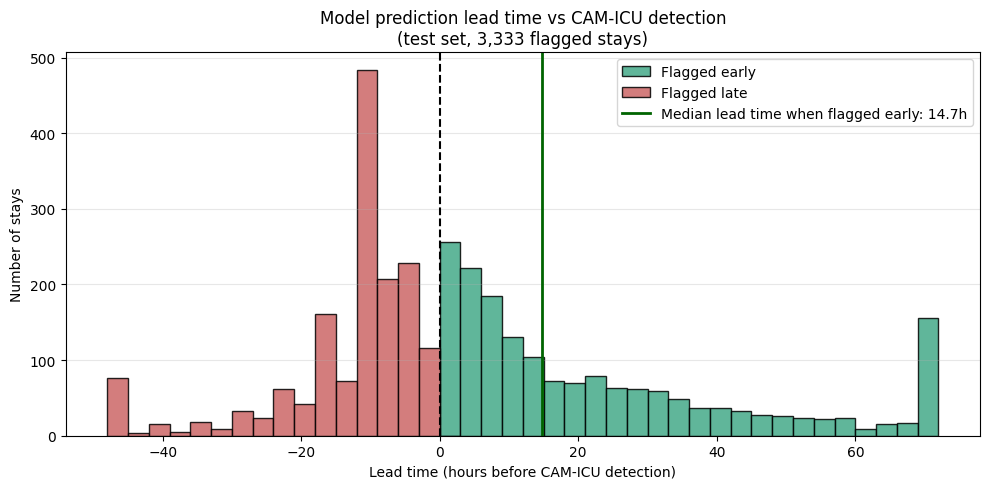

Saved ./figures/lead_time_histogram.png


In [11]:
import matplotlib.pyplot as plt
import os

# Get all stays where the model flagged at any point (both early and late)
flagged_stays = delirious_test[delirious_test["t_model"].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 5))

# Color-code positive (early) vs negative (late) lead times
flagged = flagged_stays["lead_hours"].clip(-48, 72)
ax.hist(
    flagged[flagged > 0],
    bins=range(0, 73, 3),
    color="#4a8",
    edgecolor="black",
    label="Flagged early",
    alpha=0.85,
)
ax.hist(
    flagged[flagged <= 0],
    bins=range(-48, 4, 3),
    color="#c66",
    edgecolor="black",
    label="Flagged late",
    alpha=0.85,
)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

# Mark the early-flagged median (the headline number)
early_median = flagged_stays[flagged_stays["lead_hours"] > 0]["lead_hours"].median()
ax.axvline(
    early_median,
    color="darkgreen",
    linestyle="-",
    linewidth=2,
    label=f"Median lead time when flagged early: {early_median:.1f}h",
)

ax.set_xlabel("Lead time (hours before CAM-ICU detection)")
ax.set_ylabel("Number of stays")
ax.set_title(
    f"Model prediction lead time vs CAM-ICU detection\n(test set, {len(flagged_stays):,} flagged stays)"
)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./figures/lead_time_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ./figures/lead_time_histogram.png")

## Prepare data for subgroup analysis

In [12]:
# Pull demographics for test stays
test_demo = con.execute(f"""
    SELECT 
        c.stay_id, c.gender, c.age, c.race
    FROM cohort c
    WHERE c.stay_id IN ({test_stay_ids_str})
""").df()


# Add the same race simplification we used in cohort exploration
def simplify_race(r):
    if pd.isna(r):
        return "UNKNOWN"
    r = str(r).upper()
    if "WHITE" in r or "PORTUGUESE" in r:
        return "WHITE"
    if "BLACK" in r or "AFRICAN" in r:
        return "BLACK"
    if "HISPANIC" in r or "LATINO" in r or "SOUTH AMERICAN" in r:
        return "HISPANIC"
    if "ASIAN" in r:
        return "ASIAN"
    if "UNKNOWN" in r or "UNABLE" in r or "DECLINED" in r:
        return "UNKNOWN"
    return "OTHER"


test_demo["race_simple"] = test_demo["race"].apply(simplify_race)


# Bin age
def age_bin(age):
    if age < 50:
        return "<50"
    if age < 65:
        return "50-64"
    if age < 80:
        return "65-79"
    return ">=80"


test_demo["age_bin"] = test_demo["age"].apply(age_bin)

# Merge demographics into test predictions (one row per window gets the stay's demographics)
test_preds_demo = test_preds.merge(
    test_demo[["stay_id", "gender", "race_simple", "age_bin"]], on="stay_id", how="left"
)

print(f"Test predictions with demographics: {test_preds_demo.shape}")
print("\nGender distribution (windows):")
print(test_preds_demo["gender"].value_counts().to_string())
print("\nAge bin distribution (windows):")
print(test_preds_demo["age_bin"].value_counts().to_string())
print("\nRace distribution (windows):")
print(test_preds_demo["race_simple"].value_counts().to_string())

Test predictions with demographics: (107831, 10)

Gender distribution (windows):
gender
M    61954
F    45877

Age bin distribution (windows):
age_bin
65-79    38100
50-64    32218
<50      20862
>=80     16651

Race distribution (windows):
race_simple
WHITE       69225
UNKNOWN     15059
BLACK       11093
OTHER        4488
HISPANIC     4060
ASIAN        3906


## Subgroup performance metrics

In [13]:
def subgroup_metrics(df, group_col):
    """Compute model performance metrics for each value of a grouping column."""
    rows = []
    for group_value in sorted(df[group_col].dropna().unique()):
        sub = df[df[group_col] == group_value]
        y_true = sub["delirium_next_12h"].values
        y_pred = sub["ensemble"].values

        n = len(sub)
        n_pos = y_true.sum()

        if n_pos == 0 or n_pos == n:
            # Can't compute metrics if all one class
            rows.append(
                {
                    "group": group_value,
                    "n_windows": n,
                    "pos_rate": n_pos / n,
                    "auroc": np.nan,
                    "auprc": np.nan,
                    "sensitivity": np.nan,
                    "precision": np.nan,
                }
            )
            continue

        auroc = roc_auc_score(y_true, y_pred)
        auprc = average_precision_score(y_true, y_pred)

        # Sensitivity and precision at the chosen threshold
        flagged = y_pred >= threshold
        tp = ((flagged) & (y_true == 1)).sum()
        sensitivity = tp / n_pos if n_pos > 0 else 0
        precision = tp / flagged.sum() if flagged.sum() > 0 else 0

        rows.append(
            {
                "group": group_value,
                "n_windows": n,
                "pos_rate": round(n_pos / n, 3),
                "auroc": round(auroc, 4),
                "auprc": round(auprc, 4),
                "sensitivity": round(sensitivity, 3),
                "precision": round(precision, 3),
            }
        )

    return pd.DataFrame(rows).set_index("group")


print("=== By gender ===")
print(subgroup_metrics(test_preds_demo, "gender").to_string())

print("\n=== By age bin ===")
print(subgroup_metrics(test_preds_demo, "age_bin").to_string())

print("\n=== By race ===")
print(subgroup_metrics(test_preds_demo, "race_simple").to_string())

# Overall as baseline
y_true_all = test_preds_demo["delirium_next_12h"].values
y_pred_all = test_preds_demo["ensemble"].values
print("\n=== Overall (reference) ===")
print(f"  AUROC: {roc_auc_score(y_true_all, y_pred_all):.4f}")
print(f"  AUPRC: {average_precision_score(y_true_all, y_pred_all):.4f}")
print(
    f"  Sensitivity at threshold: {((y_pred_all >= threshold) & (y_true_all == 1)).sum() / y_true_all.sum():.3f}"
)
print(
    f"  Precision at threshold:   {((y_pred_all >= threshold) & (y_true_all == 1)).sum() / (y_pred_all >= threshold).sum():.3f}"
)

=== By gender ===
       n_windows  pos_rate  auroc   auprc  sensitivity  precision
group                                                            
F          45877     0.103  0.833  0.3316        0.800      0.249
M          61954     0.104  0.845  0.3615        0.791      0.267

=== By age bin ===
       n_windows  pos_rate   auroc   auprc  sensitivity  precision
group                                                             
50-64      32218     0.102  0.8492  0.3640        0.803      0.259
65-79      38100     0.108  0.8400  0.3623        0.798      0.272
<50        20862     0.092  0.8558  0.3496        0.790      0.260
>=80       16651     0.107  0.7996  0.2871        0.775      0.232

=== By race ===
          n_windows  pos_rate   auroc   auprc  sensitivity  precision
group                                                                
ASIAN          3906     0.083  0.8331  0.2765        0.729      0.223
BLACK         11093     0.107  0.8303  0.3290        0.771      0.266

RQ3: The ensemble's performance varies across demographic subgroups. The largest disparity is by age: AUROC drops from 0.856 in patients under 50 to 0.800 in patients aged 80 and over, with corresponding declines in AUPRC (0.350 to 0.287) and sensitivity (0.79 to 0.78). The elderly are paradoxically the highest-risk group for delirium yet are predicted worst by the model. Possible causes include baseline cognitive impairment confounding CAM-ICU as a label and reduced feature contrast in this uniformly comorbid population. Gender performance is roughly equivalent across men and women. Race-based disparities are smaller in magnitude but show systematically lower sensitivity for ASIAN (0.73) and OTHER (0.76) patients, who together comprise only 8% of the test cohort, suggesting these groups may be underrepresented during training.

## Save the subgroup tables

In [14]:
import os

os.makedirs("./data", exist_ok=True)

subgroup_metrics(test_preds_demo, "gender").to_csv("./data/subgroup_gender.csv")
subgroup_metrics(test_preds_demo, "age_bin").to_csv("./data/subgroup_age.csv")
subgroup_metrics(test_preds_demo, "race_simple").to_csv("./data/subgroup_race.csv")
print("Saved subgroup CSVs.")

Saved subgroup CSVs.


# Interpretation

## Rebuild what's needed for SHAP

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

RANDOM_SEED = 42

# Reload master features and cohort
master = pd.read_parquet("./data/master_features.parquet")
cohort_df = pd.read_parquet("./data/cohort.parquet")

# Merge demographics
demo = cohort_df[
    ["stay_id", "age", "gender", "race_simple", "first_careunit", "admission_type"]
]
master = master.merge(demo, on="stay_id", how="left")

# Exclude currently-delirious windows
master = master[master["currently_delirious"] == 0].copy()

# Rebuild the same train/val/test split
patient_labels = (
    master.groupby("subject_id")["delirium_next_12h"]
    .max()
    .reset_index()
    .rename(columns={"delirium_next_12h": "ever_positive"})
)
train_patients, holdout_patients = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["ever_positive"],
    random_state=RANDOM_SEED,
)
val_patients, test_patients = train_test_split(
    holdout_patients,
    test_size=0.50,
    stratify=holdout_patients["ever_positive"],
    random_state=RANDOM_SEED,
)
train_ids = set(train_patients["subject_id"])
val_ids = set(val_patients["subject_id"])
test_ids = set(test_patients["subject_id"])


def assign_split(sid):
    if sid in train_ids:
        return "train"
    if sid in val_ids:
        return "val"
    if sid in test_ids:
        return "test"
    return None


master["split"] = master["subject_id"].map(assign_split)

# One-hot encode categoricals
CATEGORICAL_COLS = ["gender", "race_simple", "first_careunit", "admission_type"]
master_encoded = pd.get_dummies(master, columns=CATEGORICAL_COLS, dtype=int)

# Feature columns: numeric only, excluding IDs/targets
NON_FEATURE_COLS = [
    "stay_id",
    "subject_id",
    "hadm_id",
    "window_idx",
    "window_start",
    "window_end",
    "delirium_next_12h",
    "currently_delirious",
    "split",
]
feature_cols = [
    c
    for c in master_encoded.columns
    if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(master_encoded[c])
]


# Build X/y per split
def get_split(df, split_name):
    sub = df[df["split"] == split_name]
    X = sub[feature_cols].copy()
    y = sub["delirium_next_12h"].values
    return X, y


X_train, y_train = get_split(master_encoded, "train")
X_val, y_val = get_split(master_encoded, "val")
X_test, y_test = get_split(master_encoded, "test")

# Impute with training median
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Retrain XGBoost (fast)
print("Training XGBoost...")
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="auc",
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

val_proba = xgb_model.predict_proba(X_val)[:, 1]
test_proba = xgb_model.predict_proba(X_test)[:, 1]
print(f"Val AUROC: {roc_auc_score(y_val, val_proba):.4f}")
print(f"Test AUROC: {roc_auc_score(y_test, test_proba):.4f}")
print(f"\nX_test shape: {X_test.shape}")

Training XGBoost...
Val AUROC: 0.8349
Test AUROC: 0.8296

X_test shape: (107831, 128)


## SHAP feature importance

In [17]:
import shap

# Sample test windows for SHAP analysis
SAMPLE_SIZE = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), SAMPLE_SIZE, replace=False)
X_sample = X_test.iloc[sample_idx]

print(f"Computing SHAP values for {SAMPLE_SIZE:,} test windows...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values for 5,000 test windows...
SHAP values shape: (5000, 128)


## SHAP global importance (bar plot)

C:\Users\Crazy\AppData\Local\Temp\ipykernel_22736\2154140938.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


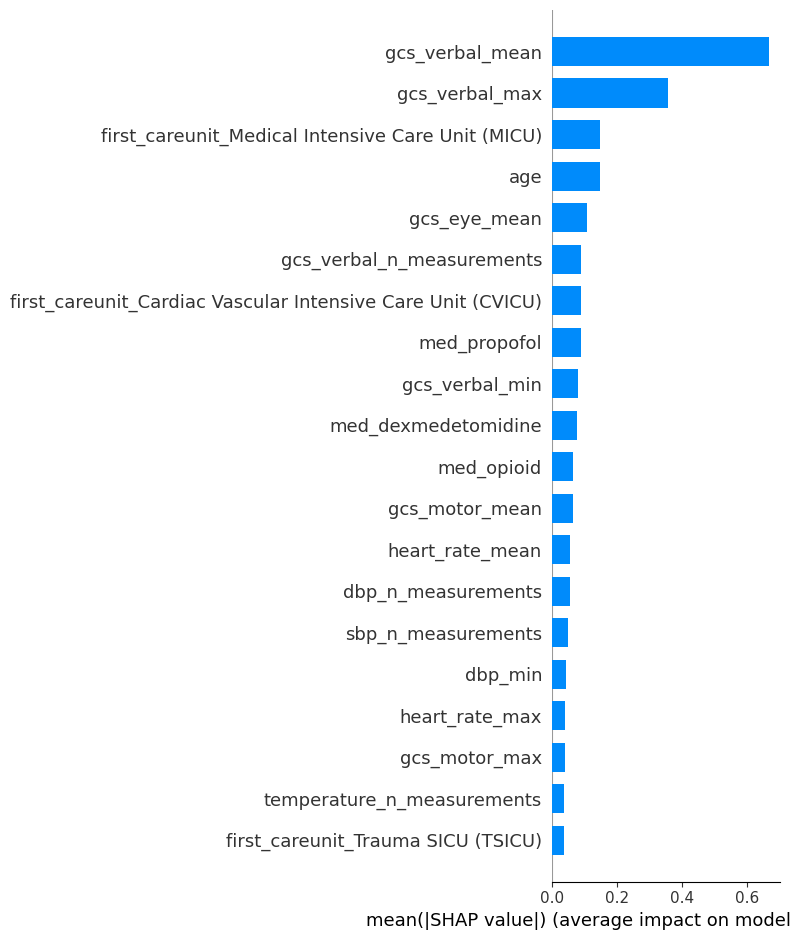

Saved ./figures/shap_bar.png


In [18]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_cols,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig("./figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ./figures/shap_bar.png")

## SHAP beeswarm (impact direction)

C:\Users\Crazy\AppData\Local\Temp\ipykernel_22736\2103522151.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


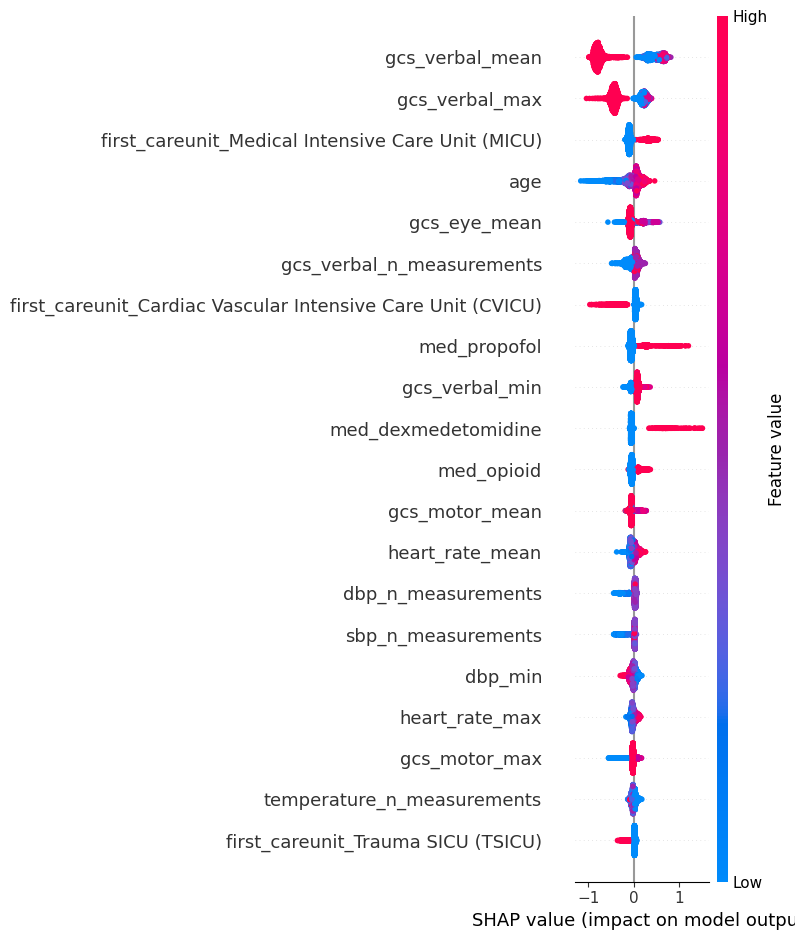

Saved ./figures/shap_beeswarm.png


In [19]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_cols,
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig("./figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ./figures/shap_beeswarm.png")

## Top features table

In [20]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "mean_abs_shap": mean_abs_shap.round(4),
    }
).sort_values("mean_abs_shap", ascending=False)

print("Top 20 features by mean absolute SHAP value:")
print(feature_importance.head(20).to_string(index=False))

feature_importance.to_csv("./data/feature_importance.csv", index=False)
print("\nSaved ./data/feature_importance.csv")

Top 20 features by mean absolute SHAP value:
                                                    feature  mean_abs_shap
                                            gcs_verbal_mean         0.6688
                                             gcs_verbal_max         0.3589
          first_careunit_Medical Intensive Care Unit (MICU)         0.1471
                                                        age         0.1471
                                               gcs_eye_mean         0.1084
                                  gcs_verbal_n_measurements         0.0912
first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)         0.0907
                                               med_propofol         0.0902
                                             gcs_verbal_min         0.0817
                                        med_dexmedetomidine         0.0763
                                                 med_opioid         0.0663
                                             gcs_motor_

Interpretation: SHAP analysis identified Glasgow Coma Scale verbal response as the dominant predictor of near-term delirium, contributing 2-3x more to predictions than any other feature. This is consistent with the clinical literature (Tang et al., 2024). GCS occupies six of the top 20 most influential features. The first care unit (MICU vs CVICU) is the second most important, reflecting strong base-rate differences between patient populations. Age, sedative medications (propofol, dexmedetomidine, opioids), and measurement frequency for vital signs round out the top features. The prominence of measurement frequency suggests the model has learned that nursing assessment intensity itself encodes information about clinical concern, in addition to the values being measured.

# Results

## 4.1 Cohort characteristics

The final analysis cohort comprised 57,054 ICU stays from 42,329 unique patients (Table 1). Median age was 63 years (IQR not yet computed but easy to add), 43% were female, and 65% were White. Median ICU length of stay was 78 hours (mean 87h). Delirium prevalence in the cohort was 36.1%, consistent with the 32% reported in systematic reviews (Wu et al., 2023). Delirious patients had substantially longer stays than non-delirious patients (median 113h vs 49h), reflecting both the bidirectional relationship between delirium and length of stay.

The cohort attrition from MIMIC-IV's 94,458 total ICU stays followed five filters (Figure 1):

- All ICU stays: 94,458
- Adults (≥18): 94,458 (no filter effect; MIMIC-IV ICU is adult-only)
- Stays with at least one CAM-ICU assessment: 72,944
- Stays with at least one usable label (not only UTA): 69,879
- ICU LOS ≥24h: 57,401
- First positive CAM-ICU not before ICU intime: 57,054

The 24-hour LOS threshold was chosen based on empirical analysis of the trade-off between sample size and per-stay data availability: this threshold retained 93% of delirious stays while excluding stays too short for meaningful prediction.

## 4.2 Model performance (RQ1)

We trained four prediction models on the test set of 8,584 ICU stays (107,831 windows after excluding currently-delirious windows). Table 2 reports AUROC and AUPRC on the held-out test set.

| Model | Test AUROC | Test AUPRC |
|---|---|---|
| Random Forest | 0.8259 | 0.3240 |
| XGBoost | 0.8296 | 0.3360 |
| LSTM (unidirectional) | 0.8378 | 0.3449 |
| **Ensemble (average)** | **0.8399** | **0.3481** |

The simple-average ensemble of the three base models achieved the highest performance on both metrics, with AUROC 0.8399 and AUPRC 0.3481 on the test set. The improvement over the strongest individual model (LSTM) was modest: +0.002 AUROC and +0.003 AUPRC. The gains were larger on the validation set (+0.005 AUROC, +0.014 AUPRC), suggesting some validation-set sensitivity that did not fully generalise to test.

The narrow ensemble advantage is explained by the high correlation between base model predictions: all three models were trained on the same windowed feature set, so their errors overlap rather than being complementary. Despite this, simple averaging consistently outperformed each base model.

Cross-comparison with the literature: our AUROC of 0.84 falls within the published range of 0.78-0.88 for delirium prediction studies (Gong et al., 2023; Tang et al., 2024; Jauk et al., 2024).

**Answer to RQ1**: Yes, the ensemble marginally improves over individual models, with the LSTM being the strongest single contributor.

## 4.3 Lead time over CAM-ICU (RQ2)

At an operating threshold chosen on the validation set to achieve 80% sensitivity, the ensemble model produced the following categorisation among 4,336 analysable delirious test stays (Table 3, Figure 2):

- **Flagged early** (model alerted before CAM-ICU): 41.0% (1,777 stays)
- **Flagged late** (model alerted after CAM-ICU): 35.9% (1,556 stays)
- **Missed** (model never flagged): 23.1% (1,003 stays)

Among the 41% of stays where the model flagged early, the median lead time was 14.7 hours, with 73% leading by at least 6 hours and 55% by at least 12 hours. The 14.7-hour median exceeds the typical 8-12 hour CAM-ICU assessment cycle, meaning in those cases the model would have alerted clinicians an entire assessment cycle earlier.

The 36% late-flagged cases represent stays where the model's signal only crystallised after delirium had become clinically apparent. These predictions are not useful clinically (the clinical team already knew). The 23% missed cases reflect the operating point trade-off: a more sensitive threshold would catch more cases but also produce more false alarms.

**Answer to RQ2**: Yes, machine learning can meaningfully reduce the detection gap. The ensemble achieves a median lead time of 14.7 hours in 41% of delirious patients. However, this benefit does not extend to all patients, and the choice of operating threshold reflects a deliberate trade-off favouring sensitivity over precision.

## 4.4 Subgroup performance (RQ3)

We computed test-set performance metrics separately for each demographic subgroup (Tables 4a-c). The most notable disparities were by age:

| Age group | n windows | Base rate | AUROC | AUPRC | Sensitivity | Precision |
|---|---|---|---|---|---|---|
| <50 | 20,862 | 9.2% | 0.856 | 0.350 | 0.79 | 0.26 |
| 50-64 | 32,218 | 10.2% | 0.849 | 0.364 | 0.80 | 0.26 |
| 65-79 | 38,100 | 10.8% | 0.840 | 0.362 | 0.80 | 0.27 |
| **≥80** | **16,651** | **10.7%** | **0.800** | **0.287** | **0.78** | **0.23** |

The model performed substantially worse for patients aged 80 and over: AUROC dropped by 0.06 compared to under-50 patients, and AUPRC by 0.06. Sensitivity at the operating threshold also fell modestly. This pattern is clinically concerning because the elderly are precisely the population most at risk for delirium and most likely to benefit from early detection.

Possible explanations include: baseline cognitive impairment in elderly patients confounding CAM-ICU as the prediction target; reduced feature contrast in this uniformly comorbid population; and the cohort's age distribution under-representing the very elderly relative to the source population.

Gender disparities were minimal (AUROC 0.833 for F vs 0.845 for M). Race-based disparities were smaller but showed lower sensitivity for Asian (0.73) and Other (0.76) patients, who together comprise only 8% of the test cohort.

**Answer to RQ3**: The model exhibits performance disparities across age, with the elderly (≥80) being the most poorly predicted group. Gender disparities are negligible. Race-based disparities are smaller but show systematically lower sensitivity for under-represented racial groups, consistent with data representativeness limitations.

**Proposed mitigations:**

- Age-stratified threshold calibration to equalise sensitivity across age bins
- Re-weighted training to up-weight under-represented subgroups
- External validation on more demographically diverse cohorts before any deployment claim
- Acknowledgement that CAM-ICU itself is less reliable in elderly patients with baseline cognitive impairment; alternative labels may be needed for this group

## 4.5 Feature importance and interpretability

SHAP analysis on the XGBoost model identified the following top features by mean absolute attribution (Figure 3):

1. GCS verbal response (mean): 0.669
2. GCS verbal response (max): 0.359
3. First care unit MICU: 0.147
4. Patient age: 0.147
5. GCS eye opening (mean): 0.108

The dominance of GCS components (six of the top 20 features) is consistent with Tang et al. (2024), who identified GCS as the single strongest predictor of delirium in elderly ICU patients. The Glasgow Coma Scale verbal response component, in particular, measures the patient's ability to respond coherently to questions, which conceptually overlaps directly with delirium itself.

Beyond GCS, the model relies on:

- **Care unit setting**: MICU as positive predictor, CVICU as negative
- **Demographics**: age (positive predictor for delirium)
- **Sedative medications**: propofol, dexmedetomidine, opioids all appear; these are confounded by indication (given to already-agitated patients)
- **Measurement frequency**: lower measurement counts associate with lower delirium risk, reflecting that nursing assessment intensity itself encodes clinical concern

The clinical interpretability of these top features supports the trustworthiness of the model's predictions: the model is not relying on spurious associations but on features with clear clinical relevance to delirium pathophysiology.